# EPA Hyperparameter Tuning via Representation Reading

Uses **representation reading** (projecting hidden states onto extracted directions) to find
optimal per-layer weights for reading EPA values from text.

Much faster than Likert-based tuning: one forward pass per utterance extracts scores from ALL layers.

**Phase 1** -- Individual layer sweep: correlation of each layer's raw reading with ground-truth EPA.
**Simple Independent** -- Combine effective layers with uniform weights.
**Phase 2** -- Greedy forward selection with per-layer weight optimization.

**Prerequisites:** `epa_tuning_dataset.json` (from `hyperparameter_tuning.ipynb` Cell 3) and
`epa_directions.pkl` must exist in the working directory.

**Estimated time:** ~5-10 minutes total (vs ~50 min for Likert-based).

In [1]:
# === Cell 1: Setup & Imports ===
import sys; sys.path.append('../..')
import os, json, pickle
from datetime import datetime
import torch, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from repe import repe_pipeline_registry
repe_pipeline_registry()
from examples.act_new.act_core import EPA
from examples.act_new.epa_calibration import BehaviorPromptGenerator
from examples.act_new.utils import format_for_reading, format_llama3_prompt, make_epa_activations
print("All imports OK.")

c:\Users\Kyra\mambaforge-pypy3\envs\repeng\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK.


In [2]:
# === Cell 2: Load Model & Directions ===
with open("epa_directions.pkl", 'rb') as f:
    directions_data = pickle.load(f)
rep_readers = directions_data['rep_readers']
hidden_layers = directions_data['hidden_layers']
model_name = directions_data['model_name']

model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left")
tokenizer.pad_token = tokenizer.eos_token

# Create reading pipeline
rep_reading_pipeline = pipeline("rep-reading", model=model, tokenizer=tokenizer)

print(f"Loaded: {model_name}, {len(hidden_layers)} layers ({hidden_layers[0]}..{hidden_layers[-1]})")

# Verify layer keys
sample_reader = list(rep_readers.values())[0]
print(f"RepReader direction layers: {sorted(sample_reader.directions.keys())[:5]}...")

Loading checkpoint shards: 100%|██████████| 4/4 [00:11<00:00,  2.83s/it]
Device set to use cuda:0


Loaded: meta-llama/Llama-3.1-8B-Instruct, 31 layers (-1..-31)
RepReader direction layers: [-31, -30, -29, -28, -27]...


In [ ]:
# Generates utterances for calibration and assigns Likert-scale
# ground-truth labels for every EPA dimension based on dictionary values.
TRAIN_DATASET_PATH = "epa_tuning_dataset_train.json"
TEST_DATASET_PATH  = "epa_tuning_dataset_test.json"
N_VARIANTS = 5          # utterances per behavior
TEST_FRACTION = 0.10    # 10% of behaviors held out for test
# --- Likert bin mapping ---
LIKERT_OPTIONS = [
    "Very low", "Low", "Somewhat low", "Neutral",
    "Somewhat high", "High", "Very high",
]
LIKERT_VALUES = {label: i + 1 for i, label in enumerate(LIKERT_OPTIONS)}
def epa_value_to_likert(value: float) -> str:
    """Map a continuous EPA value to a Likert label."""
    if value <= -3.0:
        return "Very low"
    elif value <= -1.5:
        return "Low"
    elif value <= -0.5:
        return "Somewhat low"
    elif value <= 0.5:
        return "Neutral"
    elif value <= 1.5:
        return "Somewhat high"
    elif value <= 3.0:
        return "High"
    else:
        return "Very high"
# --- LLM utterance generation ---
def epa_to_description(epa: EPA) -> str:
    def scale_term(value, neg_terms, pos_terms):
        if value <= -3.0:   return neg_terms[0]
        elif value <= -1.5: return neg_terms[1]
        elif value <= -0.5: return neg_terms[2]
        elif value <= 0.5:  return neg_terms[3]
        elif value <= 1.5:  return pos_terms[0]
        elif value <= 3.0:  return pos_terms[1]
        else:               return pos_terms[2]
    e_desc = scale_term(epa.e,
        ["very bad", "bad", "somewhat bad", "neither good nor bad"],
        ["somewhat good", "good", "very good"])
    p_desc = scale_term(epa.p,
        ["very impotent", "impotent", "somewhat impotent", "neither potent nor impotent"],
        ["somewhat potent", "potent", "very potent"])
    a_desc = scale_term(epa.a,
        ["very passive", "passive", "somewhat passive", "neither active nor passive"],
        ["somewhat active", "active", "very active"])
    return f"{e_desc}, {p_desc}, and {a_desc}"
def generate_with_llm(behavior: str, epa: EPA) -> str:
    epa_description = epa_to_description(epa)
    behavior_display = behavior.replace("_", " ")
    prompt = format_llama3_prompt(
        None,
        f"You are simulating a human person engaging in a conversation with another human person. Generate a single conversational utterance that when observed by a third party, is most appropriately described as "
        f"'you {behavior_display} them' towards the other person, where '{behavior_display} is a verb or action, with an affective tone that is {epa_description}. "
        f"Respond with only the utterance, no explanation or quotation marks."
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(**inputs, max_new_tokens=100,
                              pad_token_id=tokenizer.eos_token_id)
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return response.strip().strip('"\'')
# --- Stratified train/test split by behavior EPA coverage ---
def stratified_behavior_split(behaviors, generator, test_fraction=0.10, seed=42):
    """
    Split behaviors into train/test sets so both sets cover the full
    EPA space.  Uses k-means to cluster behaviors by EPA, then
    proportionally allocates from each cluster.
    """
    from sklearn.cluster import KMeans
    import numpy as np, random
    rng = random.Random(seed)
    # Collect EPA vectors
    epa_vecs, valid_behaviors = [], []
    for b in behaviors:
        epa = generator.get_behavior_epa(b)
        if epa is not None:
            epa_vecs.append([epa.e, epa.p, epa.a])
            valid_behaviors.append(b)
    epa_arr = np.array(epa_vecs)
    n_test = max(1, int(len(valid_behaviors) * test_fraction))
    n_clusters = min(10, len(valid_behaviors))  # 10 EPA-space clusters
    kmeans = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    labels = kmeans.fit_predict(epa_arr)
    # Group behaviors by cluster
    clusters = {}
    for idx, label in enumerate(labels):
        clusters.setdefault(label, []).append(valid_behaviors[idx])
    train_behaviors, test_behaviors = [], []
    for cluster_id, members in clusters.items():
        rng.shuffle(members)
        n_take = max(1, round(len(members) * test_fraction))
        test_behaviors.extend(members[:n_take])
        train_behaviors.extend(members[n_take:])
    return train_behaviors, test_behaviors
# --- Generate dataset ---
generator = BehaviorPromptGenerator()
generator.set_llm_generate_function(generate_with_llm)
behaviors = generator.available_behaviors
train_behaviors, test_behaviors = stratified_behavior_split(
    behaviors, generator, test_fraction=TEST_FRACTION
)
print(f"Behaviors  — total: {len(behaviors)}, "
      f"train: {len(train_behaviors)}, test: {len(test_behaviors)}")
print(f"Utterances — {N_VARIANTS} variants each → "
      f"train ≈ {len(train_behaviors)*N_VARIANTS}, "
      f"test ≈ {len(test_behaviors)*N_VARIANTS}")
def generate_utterances(behavior_list, desc_label):
    """Generate N_VARIANTS utterances per behavior."""
    utterances = []
    for behavior in tqdm(behavior_list, desc=f"Generating {desc_label}"):
        epa = generator.get_behavior_epa(behavior)
        if epa is None:
            continue
        for v in range(N_VARIANTS):
            text = generator.generate_utterance(behavior, variant=v)
            if text is None or text.startswith("["):
                continue
            utterances.append({
                "text": text,
                "behavior": behavior,
                "variant": v,
                "target_epa": {"e": float(epa.e), "p": float(epa.p), "a": float(epa.a)},
                "likert_targets": {
                    "evaluation": epa_value_to_likert(epa.e),
                    "potency": epa_value_to_likert(epa.p),
                    "activity": epa_value_to_likert(epa.a),
                },
            })
    return utterances
train_utterances = generate_utterances(train_behaviors, "train")
test_utterances  = generate_utterances(test_behaviors,  "test")
def save_split(path, utterances, split_name, behavior_list):
    dataset = {
        "metadata": {
            "model_name": model_name,
            "generated_at": datetime.now().isoformat(),
            "split": split_name,
            "n_behaviors": len(behavior_list),
            "n_variants": N_VARIANTS,
            "n_utterances": len(utterances),
        },
        "utterances": utterances,
    }
    with open(path, "w") as f:
        json.dump(dataset, f, indent=2)
    return dataset
save_split(TRAIN_DATASET_PATH, train_utterances, "train", train_behaviors)
save_split(TEST_DATASET_PATH,  test_utterances,  "test",  test_behaviors)
print(f"\nSaved {len(train_utterances)} train utterances → {TRAIN_DATASET_PATH}")
print(f"Saved {len(test_utterances)} test utterances  → {TEST_DATASET_PATH}")
# Quick EPA coverage check
import numpy as np
for name, utts in [("Train", train_utterances), ("Test", test_utterances)]:
    es = [u["target_epa"]["e"] for u in utts]
    ps = [u["target_epa"]["p"] for u in utts]
    acs = [u["target_epa"]["a"] for u in utts]
    print(f"\n{name} EPA ranges:  "
          f"E=[{min(es):.1f}, {max(es):.1f}]  "
          f"P=[{min(ps):.1f}, {max(ps):.1f}]  "
          f"A=[{min(acs):.1f}, {max(acs):.1f}]")
print("\nSample entries:")
for u in train_utterances[:3]:
    print(f"  [{u['behavior']} v{u['variant']}] \"{u['text'][:80]}...\"")
    print(f"    EPA: {u['target_epa']}  Likert: {u['likert_targets']}")


Behaviors  — total: 260, train: 234, test: 26
Utterances — 5 variants each → train ≈ 1170, test ≈ 130


Generating test: 100%|██████████| 26/26 [01:23<00:00,  3.22s/it]


Saved 1170 train utterances → epa_tuning_dataset_train.json
Saved 130 test utterances  → epa_tuning_dataset_test.json

Train EPA ranges:  E=[-3.0, 3.3]  P=[-2.2, 2.8]  A=[-2.1, 3.0]

Test EPA ranges:  E=[-2.6, 3.0]  P=[-0.9, 2.4]  A=[-0.7, 2.7]

Sample entries:
  [soothe v0] "Hey, it's going to be okay, I'm here with you...."
    EPA: {'e': 3.08, 'p': 1.85, 'a': -1.0}  Likert: {'evaluation': 'Very high', 'potency': 'High', 'activity': 'Somewhat low'}
  [soothe v1] "You're doing the best you can, and that's something to be really proud of...."
    EPA: {'e': 3.08, 'p': 1.85, 'a': -1.0}  Likert: {'evaluation': 'Very high', 'potency': 'High', 'activity': 'Somewhat low'}
  [soothe v2] "Hey, it's okay, you're doing the best you can and that's all anyone can ask for...."
    EPA: {'e': 3.08, 'p': 1.85, 'a': -1.0}  Likert: {'evaluation': 'Very high', 'potency': 'High', 'activity': 'Somewhat low'}


In [3]:
# === Cell 3: Load Dataset & Prepare Ground Truth ===
TRAIN_DATASET_PATH = "epa_tuning_dataset_train.json"
TEST_DATASET_PATH  = "epa_tuning_dataset_test.json"

with open(TRAIN_DATASET_PATH, 'r') as f:
    train_dataset = json.load(f)
with open(TEST_DATASET_PATH, 'r') as f:
    test_dataset = json.load(f)

train_utterances = train_dataset['utterances']
test_utterances  = test_dataset['utterances']

DIMENSIONS = ["evaluation", "potency", "activity"]
DIM_KEY = {"evaluation": "e", "potency": "p", "activity": "a"}

# Ground truth EPA values (continuous, from ACT dictionary)
train_ground_truth = {dim: [] for dim in DIMENSIONS}
test_ground_truth  = {dim: [] for dim in DIMENSIONS}

for u in train_utterances:
    for dim in DIMENSIONS:
        train_ground_truth[dim].append(u['target_epa'][DIM_KEY[dim]])

for u in test_utterances:
    for dim in DIMENSIONS:
        test_ground_truth[dim].append(u['target_epa'][DIM_KEY[dim]])

print(f"Loaded {len(train_utterances)} train / {len(test_utterances)} test utterances")
for dim in DIMENSIONS:
    tr = train_ground_truth[dim]
    te = test_ground_truth[dim]
    print(f"  {dim:12s}: train range=[{min(tr):.2f}, {max(tr):.2f}], mean={np.mean(tr):.2f}"
          f"  |  test range=[{min(te):.2f}, {max(te):.2f}], mean={np.mean(te):.2f}")


Loaded 1170 train / 130 test utterances
  evaluation  : train range=[-3.02, 3.26], mean=0.22  |  test range=[-2.61, 3.02], mean=0.08
  potency     : train range=[-2.22, 2.75], mean=0.83  |  test range=[-0.95, 2.40], mean=0.82
  activity    : train range=[-2.10, 2.99], mean=0.91  |  test range=[-0.69, 2.73], mean=1.04


In [4]:
# === Cell 4: Extract Per-Layer Reading Scores for All Utterances ===
# One forward pass per utterance extracts readings from ALL layers simultaneously.
# This is the key speed advantage over Likert-based tuning.

all_layers = sorted(rep_readers[DIMENSIONS[0]].directions.keys())
print(f"Extracting readings from {len(all_layers)} layers for "
      f"{len(train_utterances)} train + {len(test_utterances)} test utterances...")

def extract_raw_scores(utterance_list, label=""):
    """Extract per-layer scores for each dimension from a list of utterances."""
    formatted_texts = [format_for_reading(u['text']) for u in utterance_list]

    scores = {}
    for dim in DIMENSIONS:
        reader = rep_readers[dim]
        dim_scores = rep_reading_pipeline(
            formatted_texts,
            hidden_layers=all_layers,
            rep_reader=reader,
            batch_size=8,
            padding=True,
            truncation=True,
        )
        layer_arrays = {layer: [] for layer in all_layers}
        for utt_scores in dim_scores:
            for layer in all_layers:
                layer_arrays[layer].append(float(utt_scores[layer]))
        scores[dim] = {layer: np.array(vals) for layer, vals in layer_arrays.items()}
        print(f"  {label} {dim}: extracted {len(all_layers)} layers x {len(utterance_list)} utterances")
    return scores

train_raw_scores = extract_raw_scores(train_utterances, label="[train]")
test_raw_scores  = extract_raw_scores(test_utterances,  label="[test]")

print("\nExtraction complete!")
# Quick sanity: show range of readings for first layer
for split_name, scores in [("Train", train_raw_scores), ("Test", test_raw_scores)]:
    for dim in DIMENSIONS:
        first_layer = all_layers[0]
        vals = scores[dim][first_layer]
        print(f"  {split_name} {dim} layer {first_layer}: range=[{vals.min():.3f}, {vals.max():.3f}]")


Extracting readings from 31 layers for 1170 train + 130 test utterances...
  [train] evaluation: extracted 31 layers x 1170 utterances
  [train] potency: extracted 31 layers x 1170 utterances
  [train] activity: extracted 31 layers x 1170 utterances
  [test] evaluation: extracted 31 layers x 130 utterances
  [test] potency: extracted 31 layers x 130 utterances
  [test] activity: extracted 31 layers x 130 utterances

Extraction complete!
  Train evaluation layer -31: range=[-0.051, 0.045]
  Train potency layer -31: range=[-0.083, 0.053]
  Train activity layer -31: range=[-0.026, 0.073]
  Test evaluation layer -31: range=[-0.040, 0.016]
  Test potency layer -31: range=[-0.055, -0.001]
  Test activity layer -31: range=[-0.030, 0.045]


In [5]:
# === Cell 5: Phase 1 -- Individual Layer Correlation (Train) ===
# For each layer, compute Spearman correlation between raw reading and ground truth.
# No coefficients needed here -- just measuring which layers have the best signal.

train_gt_arrays = {dim: np.array(train_ground_truth[dim]) for dim in DIMENSIONS}

phase1 = {dim: {} for dim in DIMENSIONS}
for dim in DIMENSIONS:
    for layer in all_layers:
        readings = train_raw_scores[dim][layer]
        rho, pval = spearmanr(readings, train_gt_arrays[dim])
        phase1[dim][layer] = {"rho": float(rho), "pval": float(pval)}

# Print ranked results
print("Phase 1: Per-Layer Spearman Correlation with Ground-Truth EPA (Train Split)")
for dim in DIMENSIONS:
    ranked = sorted(phase1[dim].items(), key=lambda x: abs(x[1]['rho']), reverse=True)
    print(f"\n{'='*60}")
    print(f"{dim.upper()} -- Top 15 layers:")
    print(f"{'='*60}")
    for layer, info in ranked[:15]:
        sign = "+" if info['rho'] > 0 else "-"
        bar = "#" * int(abs(info['rho']) * 40)
        print(f"  Layer {layer:4d}: rho={info['rho']:+.3f} (p={info['pval']:.4f}) {bar}")


Phase 1: Per-Layer Spearman Correlation with Ground-Truth EPA (Train Split)

EVALUATION -- Top 15 layers:
  Layer  -17: rho=+0.674 (p=0.0000) ##########################
  Layer  -18: rho=+0.672 (p=0.0000) ##########################
  Layer  -16: rho=+0.667 (p=0.0000) ##########################
  Layer   -6: rho=+0.657 (p=0.0000) ##########################
  Layer  -14: rho=+0.656 (p=0.0000) ##########################
  Layer  -11: rho=+0.656 (p=0.0000) ##########################
  Layer   -5: rho=+0.656 (p=0.0000) ##########################
  Layer  -15: rho=+0.655 (p=0.0000) ##########################
  Layer   -7: rho=+0.655 (p=0.0000) ##########################
  Layer  -23: rho=+0.654 (p=0.0000) ##########################
  Layer  -20: rho=+0.653 (p=0.0000) ##########################
  Layer  -13: rho=+0.653 (p=0.0000) ##########################
  Layer  -12: rho=+0.651 (p=0.0000) ##########################
  Layer   -8: rho=+0.649 (p=0.0000) #########################
  Layer  -10:

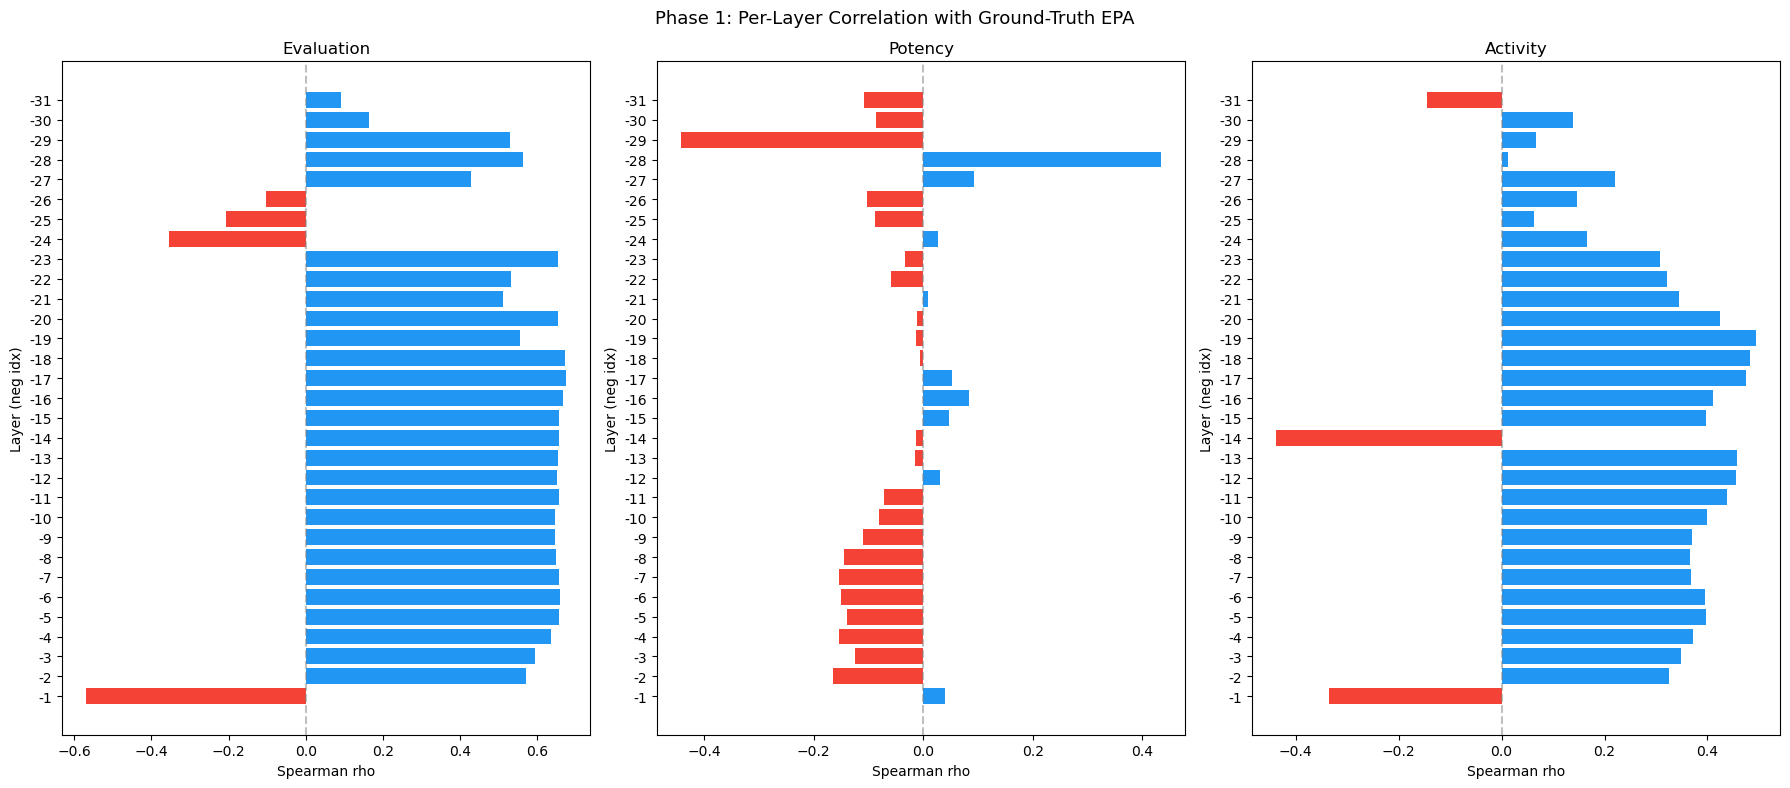

Saved reading_phase1.png


In [8]:
# === Cell 6: Phase 1 Visualization ===

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for idx, dim in enumerate(DIMENSIONS):
    sorted_layers = sorted(all_layers)
    rhos = [phase1[dim][l]['rho'] for l in sorted_layers]
    colors = ['#2196F3' if r > 0 else '#F44336' for r in rhos]
    axes[idx].barh([str(l) for l in sorted_layers], rhos, color=colors)
    axes[idx].set_xlabel("Spearman rho")
    axes[idx].set_ylabel("Layer (neg idx)")
    axes[idx].set_title(f"{dim.capitalize()}")
    axes[idx].axvline(0, color='gray', ls='--', alpha=0.5)
    axes[idx].invert_yaxis()
plt.suptitle("Phase 1: Per-Layer Correlation with Ground-Truth EPA", fontsize=13)
plt.tight_layout()
plt.savefig("reading_phase1.png", dpi=150, bbox_inches='tight'); plt.show()
print("Saved reading_phase1.png")

In [6]:
# === Cell 7: Simple Independent -- Uniform Weighted Average ===
# Average the readings from the top-K layers (by absolute correlation on train).
# Also test weighted average using sign-corrected readings.
TOP_K_VALUES = [1, 3, 5, 10, 15, 20, len(all_layers)]
INTERFERENCE_PENALTY = 0.5
test_gt_arrays = {dim: np.array(test_ground_truth[dim]) for dim in DIMENSIONS}
print("Simple Independent: Uniform average of top-K layers")
print(f"{'K':>4s}  {'--- TRAIN ---':^34s}  {'--- TEST ---':^34s}")
print(f"{'':>4s}  {'Eval':>10s}  {'Pote':>10s}  {'Acti':>10s}  {'Eval':>10s}  {'Pote':>10s}  {'Acti':>10s}")
print("-" * 76)
simple_results = {}
for K in TOP_K_VALUES:
    combined_train = {}
    combined_test = {}
    for dim in DIMENSIONS:
        # Select top-K layers by absolute correlation (from train phase1)
        ranked = sorted(phase1[dim].items(), key=lambda x: abs(x[1]['rho']), reverse=True)[:K]
        top_layers = [l for l, _ in ranked]
        # Train
        layer_readings_train = []
        for layer in top_layers:
            sign = 1.0 if phase1[dim][layer]['rho'] > 0 else -1.0
            layer_readings_train.append(sign * train_raw_scores[dim][layer])
        avg_train = np.mean(layer_readings_train, axis=0)
        rho_train, _ = spearmanr(avg_train, train_gt_arrays[dim])
        combined_train[dim] = {"rho": float(rho_train), "top_layers": top_layers}
        # Test
        layer_readings_test = []
        for layer in top_layers:
            sign = 1.0 if phase1[dim][layer]['rho'] > 0 else -1.0
            layer_readings_test.append(sign * test_raw_scores[dim][layer])
        avg_test = np.mean(layer_readings_test, axis=0)
        rho_test, _ = spearmanr(avg_test, test_gt_arrays[dim])
        combined_test[dim] = {"rho": float(rho_test), "top_layers": top_layers}
    simple_results[K] = {"train": combined_train, "test": combined_test}
    print(f"{K:4d}  {combined_train['evaluation']['rho']:+10.3f}  "
          f"{combined_train['potency']['rho']:+10.3f}  "
          f"{combined_train['activity']['rho']:+10.3f}  "
          f"{combined_test['evaluation']['rho']:+10.3f}  "
          f"{combined_test['potency']['rho']:+10.3f}  "
          f"{combined_test['activity']['rho']:+10.3f}")
print("\nNote: |rho| may decrease with more layers if weak layers add noise.")


Simple Independent: Uniform average of top-K layers
   K            --- TRAIN ---                        --- TEST ---           
            Eval        Pote        Acti        Eval        Pote        Acti
----------------------------------------------------------------------------
   1      +0.674      +0.442      +0.494      +0.676      +0.429      +0.549
   3      +0.679      +0.212      +0.494      +0.685      +0.429      +0.550
   5      +0.682      +0.179      +0.484      +0.711      +0.401      +0.581
  10      +0.675      +0.154      +0.460      +0.713      +0.385      +0.569
  15      +0.671      +0.156      +0.435      +0.708      +0.381      +0.562
  20      +0.646      +0.151      +0.411      +0.697      +0.379      +0.586
  31      +0.649      +0.129      +0.407      +0.698      +0.347      +0.589

Note: |rho| may decrease with more layers if weak layers add noise.


In [7]:
# === Cell 8: Phase 2 -- Greedy Forward Selection with Per-Layer Weights ===
# Start from the single best layer, greedily add layers with optimized weights.
# Selection is based on TRAIN data only.
TOP_K = 15         # candidate layers from Phase 1
MAX_LAYERS = 10    # max layers to select
MIN_IMPROVEMENT = 0.000  # min rho improvement to accept a layer
WEIGHT_CANDIDATES = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
def compute_weighted_reading(selected_lw, dim, raw_scores_split):
    """Compute weighted average of sign-corrected layer readings."""
    n = len(list(raw_scores_split[dim].values())[0])
    total = np.zeros(n)
    total_weight = 0.0
    for layer, weight in selected_lw.items():
        sign = 1.0 if phase1[dim][layer]['rho'] > 0 else -1.0
        total += weight * sign * raw_scores_split[dim][layer]
        total_weight += weight
    return total / total_weight if total_weight > 0 else total
def eval_reading_combo(selected_lw, steer_dim):
    """Evaluate a layer+weight combination on TRAIN data."""
    corrs = {}; delts = {}
    for dim in DIMENSIONS:
        avg = compute_weighted_reading(selected_lw, dim, train_raw_scores)
        rho, _ = spearmanr(avg, train_gt_arrays[dim])
        corrs[dim] = float(rho)
        best_single = max(phase1[dim].items(), key=lambda x: abs(x[1]['rho']))
        delts[dim] = float(rho - abs(best_single[1]['rho']))
    others = [d for d in DIMENSIONS if d != steer_dim]
    cross_penalty = np.mean([max(0, -delts[d]) for d in others])
    score = corrs[steer_dim] - INTERFERENCE_PENALTY * cross_penalty
    return {"correlations": corrs, "deltas": delts, "score": score}
print(f"Phase 2: Greedy selection (top-{TOP_K}, max {MAX_LAYERS} layers) — fitted on TRAIN")
print(f"Weight candidates: {WEIGHT_CANDIDATES}")
print("")
greedy_results = {}
for steer_dim in DIMENSIONS:
    print(f"\n{'='*60}")
    print(f"Greedy: {steer_dim.upper()}")
    print(f"{'='*60}")
    ranked = sorted(phase1[steer_dim].items(),
                    key=lambda x: abs(x[1]['rho']), reverse=True)[:TOP_K]
    candidates = [l for l, _ in ranked]
    print(f"Candidate layers: {candidates}")
    best_layer = candidates[0]
    selected = {best_layer: 1.0}
    ev = eval_reading_combo(selected, steer_dim)
    cur_score = ev['score']
    print(f"Step 0: layer {best_layer} w=1.0 => rho={ev['correlations'][steer_dim]:+.3f}, score={cur_score:.4f}")
    history = [{"step": 0, "selected": dict(selected), "score": cur_score, **ev}]
    for step in range(1, MAX_LAYERS):
        remaining = [l for l in candidates if l not in selected]
        if not remaining: break
        best_add_score = cur_score
        best_add_layer = None
        best_add_weight = None
        for cand in remaining:
            for w in WEIGHT_CANDIDATES:
                trial = {**selected, cand: w}
                ev = eval_reading_combo(trial, steer_dim)
                if ev['score'] > best_add_score:
                    best_add_score = ev['score']
                    best_add_layer = cand
                    best_add_weight = w
        if best_add_layer is None or (best_add_score - cur_score) < MIN_IMPROVEMENT:
            print(f"Step {step}: no improvement >= {MIN_IMPROVEMENT}, stopping.")
            break
        selected[best_add_layer] = best_add_weight
        cur_score = best_add_score
        ev = eval_reading_combo(selected, steer_dim)
        print(f"Step {step}: +layer {best_add_layer} w={best_add_weight} => "
              f"rho={ev['correlations'][steer_dim]:+.3f}, score={cur_score:.4f}")
        history.append({"step": step, "selected": dict(selected), "score": cur_score, **ev})
    # Evaluate on test
    test_avg = compute_weighted_reading(selected, steer_dim, test_raw_scores)
    test_rho, _ = spearmanr(test_avg, test_gt_arrays[steer_dim])
    greedy_results[steer_dim] = {
        "selected": dict(selected), "history": history, "score": cur_score,
        "train_rho": ev['correlations'][steer_dim], "test_rho": float(test_rho),
    }
    print(f"\nFinal: {len(selected)} layers, train_rho={ev['correlations'][steer_dim]:+.3f}, test_rho={test_rho:+.3f}")
    for l, w in sorted(selected.items()):
        sign_str = "+" if phase1[steer_dim][l]['rho'] > 0 else "-"
        print(f"  Layer {l:4d}: weight={w}, sign={sign_str}, "
              f"individual rho={phase1[steer_dim][l]['rho']:+.3f}")
print("\nPhase 2 complete!")

Phase 2: Greedy selection (top-15, max 10 layers) — fitted on TRAIN
Weight candidates: [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]


Greedy: EVALUATION
Candidate layers: [-17, -18, -16, -6, -14, -11, -5, -15, -7, -23, -20, -13, -12, -8, -10]
Step 0: layer -17 w=1.0 => rho=+0.674, score=0.5714
Step 1: +layer -16 w=1.0 => rho=+0.674, score=0.6277
Step 2: +layer -20 w=0.5 => rho=+0.681, score=0.6466
Step 3: +layer -23 w=0.25 => rho=+0.686, score=0.6473
Step 4: no improvement >= 0.0, stopping.

Final: 4 layers, train_rho=+0.671, test_rho=+0.696
  Layer  -23: weight=0.25, sign=+, individual rho=+0.654
  Layer  -20: weight=0.5, sign=+, individual rho=+0.653
  Layer  -17: weight=1.0, sign=+, individual rho=+0.674
  Layer  -16: weight=1.0, sign=+, individual rho=+0.667

Greedy: POTENCY
Candidate layers: [-29, -28, -2, -4, -7, -6, -8, -5, -3, -9, -31, -26, -27, -25, -30]
Step 0: layer -29 w=1.0 => rho=+0.442, score=0.2988
Step 1: +layer -28 w=0.5 => rho=+0.454, score=0.3316
Step 2: +layer -27 w=0.25 => rh

In [10]:
# === Cell 9: Final Evaluation & Comparison ===

print("=== Final Results ===\n")

# Compare: single best layer vs simple top-5 vs greedy
methods = {}

# 1. Single best layer
methods["Single Best"] = {}
for dim in DIMENSIONS:
    best = max(phase1[dim].items(), key=lambda x: abs(x[1]['rho']))
    methods["Single Best"][dim] = {"rho": abs(best[1]['rho']), "layers": {best[0]: 1.0}}

# 2. Simple top-5
methods["Top-5 Avg"] = {}
for dim in DIMENSIONS:
    ranked = sorted(phase1[dim].items(), key=lambda x: abs(x[1]['rho']), reverse=True)[:5]
    top5 = {l: 1.0 for l, _ in ranked}
    avg = compute_weighted_reading(top5, dim)
    rho, _ = spearmanr(avg, gt_arrays[dim])
    methods["Top-5 Avg"][dim] = {"rho": float(rho), "layers": top5}

# 3. Greedy
methods["Greedy"] = {}
for dim in DIMENSIONS:
    sel = greedy_results[dim]['selected']
    avg = compute_weighted_reading(sel, dim)
    rho, _ = spearmanr(avg, gt_arrays[dim])
    methods["Greedy"][dim] = {"rho": float(rho), "layers": sel}

# Print comparison table
print(f"{'Method':<15s}  {'Eval':>8s}  {'Pote':>8s}  {'Acti':>8s}")
print("-" * 45)
for name, dims in methods.items():
    print(f"{name:<15s}  {dims['evaluation']['rho']:+8.3f}  "
          f"{dims['potency']['rho']:+8.3f}  "
          f"{dims['activity']['rho']:+8.3f}")

# Cross-dimension check for greedy
print("\n--- Greedy Cross-Dimension Interference ---")
for steer_dim in DIMENSIONS:
    sel = greedy_results[steer_dim]['selected']
    print(f"\n{steer_dim.upper()} layers applied to read other dimensions:")
    for dim in DIMENSIONS:
        avg = compute_weighted_reading(sel, dim)
        rho, _ = spearmanr(avg, gt_arrays[dim])
        marker = " <-- target" if dim == steer_dim else ""
        print(f"  {dim:12s}: rho={rho:+.3f}{marker}")

=== Final Results ===

Method               Eval      Pote      Acti
---------------------------------------------
Single Best        +0.692    +0.454    +0.547
Top-5 Avg          +0.681    +0.313    +0.476
Greedy             +0.693    +0.478    +0.535

--- Greedy Cross-Dimension Interference ---

EVALUATION layers applied to read other dimensions:
  evaluation  : rho=+0.693 <-- target
  potency     : rho=+0.281
  activity    : rho=+0.429

POTENCY layers applied to read other dimensions:
  evaluation  : rho=+0.658
  potency     : rho=+0.478 <-- target
  activity    : rho=+0.529

ACTIVITY layers applied to read other dimensions:
  evaluation  : rho=+0.638
  potency     : rho=+0.207
  activity    : rho=+0.535 <-- target


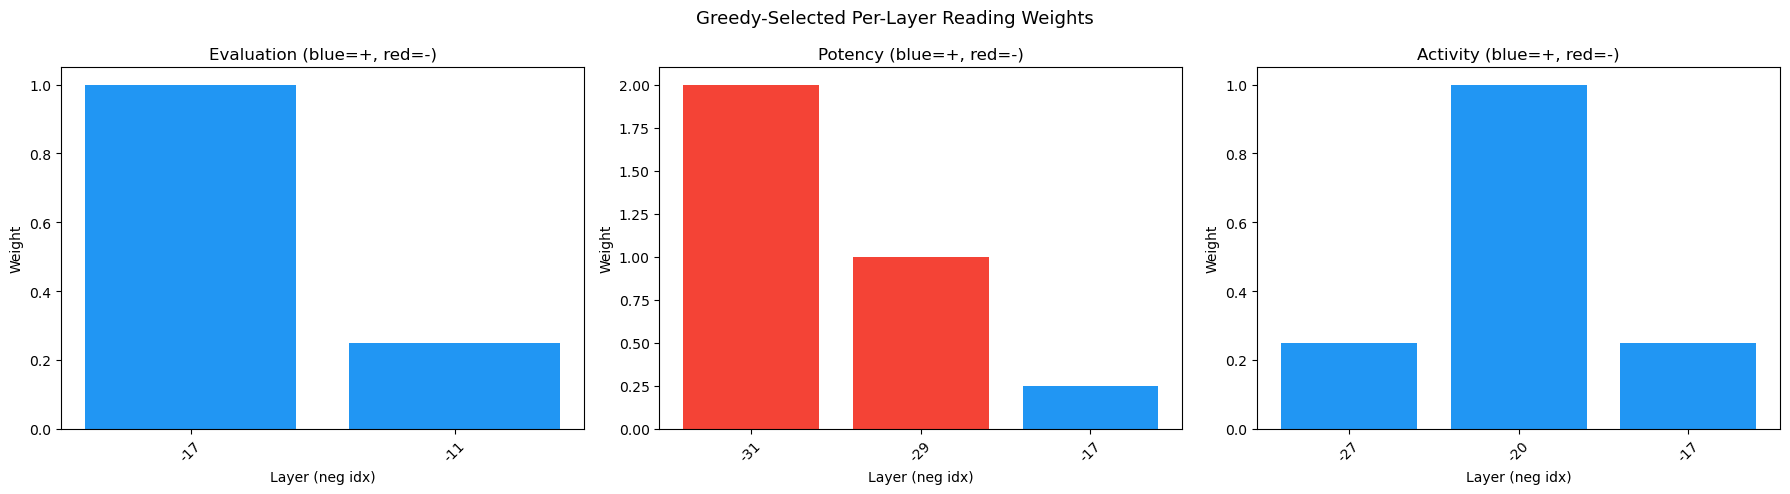

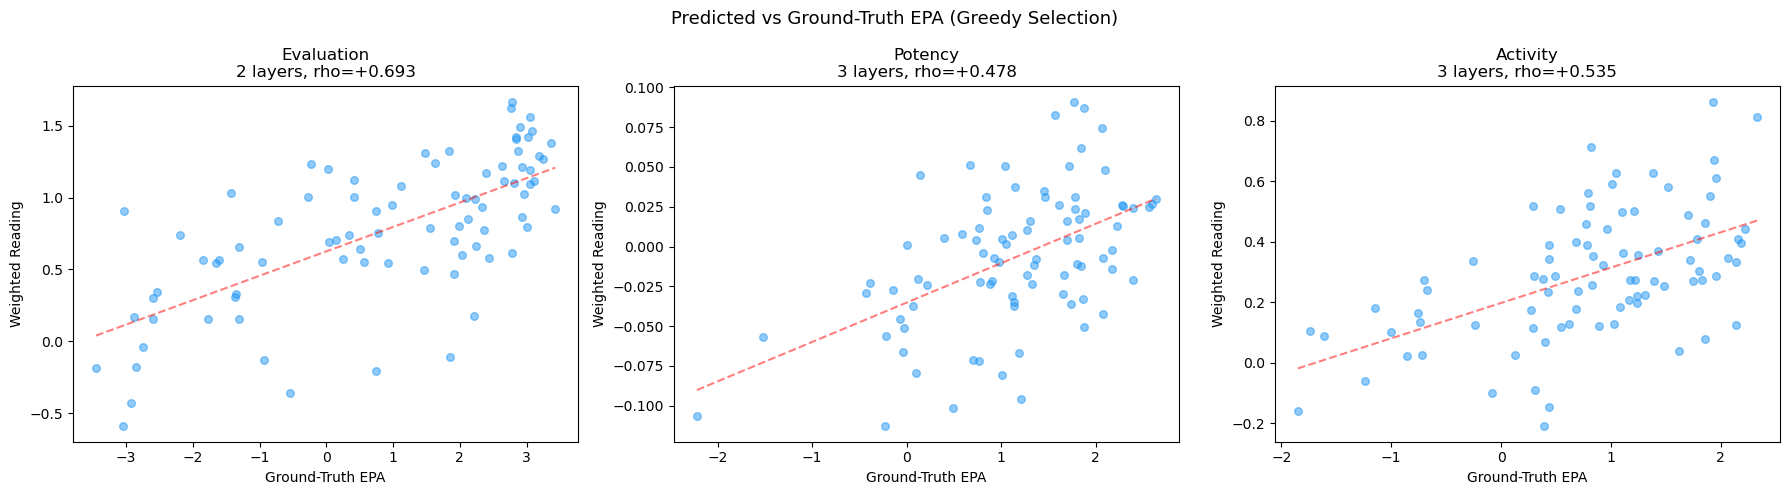

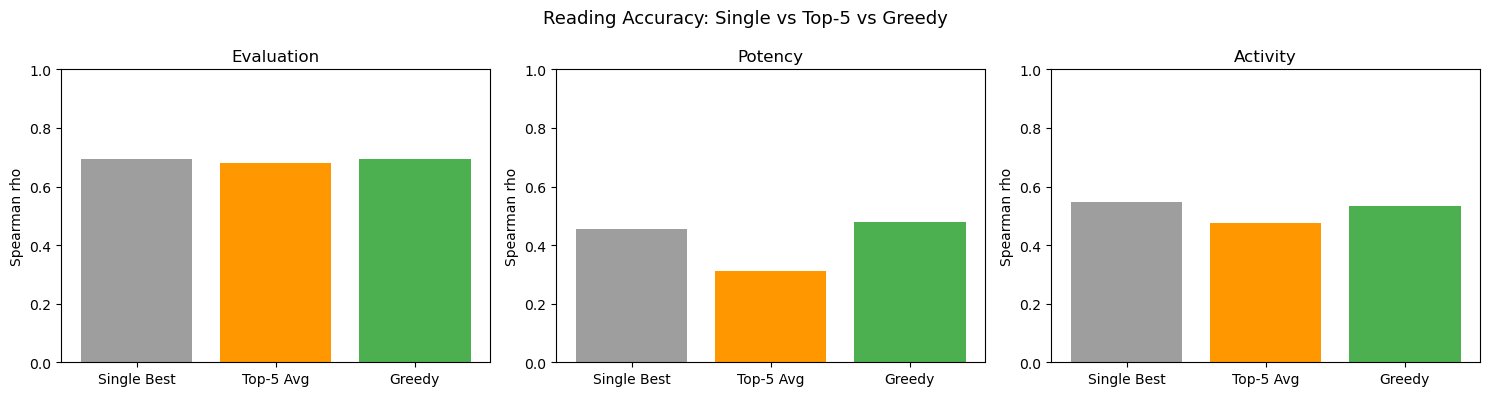

Visualizations saved.


In [11]:
# === Cell 10: Visualization ===

# --- Per-layer weight profile ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, dim in enumerate(DIMENSIONS):
    sel = greedy_results[dim]['selected']
    layers_sorted = sorted(sel.keys())
    weights = [sel[l] for l in layers_sorted]
    signs = [1 if phase1[dim][l]['rho'] > 0 else -1 for l in layers_sorted]
    colors = ['#2196F3' if s > 0 else '#F44336' for s in signs]
    axes[idx].bar([str(l) for l in layers_sorted], weights, color=colors)
    axes[idx].set_xlabel("Layer (neg idx)"); axes[idx].set_ylabel("Weight")
    axes[idx].set_title(f"{dim.capitalize()} (blue=+, red=-)")
    axes[idx].tick_params(axis='x', rotation=45)
plt.suptitle("Greedy-Selected Per-Layer Reading Weights", fontsize=13)
plt.tight_layout()
plt.savefig("reading_weights.png", dpi=150, bbox_inches='tight'); plt.show()

# --- Scatter: predicted vs ground truth ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, dim in enumerate(DIMENSIONS):
    sel = greedy_results[dim]['selected']
    predicted = compute_weighted_reading(sel, dim)
    gt = gt_arrays[dim]
    rho, _ = spearmanr(predicted, gt)
    axes[idx].scatter(gt, predicted, alpha=0.5, s=30, c='#2196F3')
    # Fit line for visual
    z = np.polyfit(gt, predicted, 1)
    x_line = np.linspace(gt.min(), gt.max(), 100)
    axes[idx].plot(x_line, np.polyval(z, x_line), 'r--', alpha=0.5)
    axes[idx].set_xlabel("Ground-Truth EPA")
    axes[idx].set_ylabel("Weighted Reading")
    axes[idx].set_title(f"{dim.capitalize()}\n{len(sel)} layers, rho={rho:+.3f}")
plt.suptitle("Predicted vs Ground-Truth EPA (Greedy Selection)", fontsize=13)
plt.tight_layout()
plt.savefig("reading_scatter.png", dpi=150, bbox_inches='tight'); plt.show()

# --- Method comparison bar chart ---
method_names = list(methods.keys())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, dim in enumerate(DIMENSIONS):
    rhos = [methods[m][dim]['rho'] for m in method_names]
    axes[idx].bar(method_names, rhos, color=['#9E9E9E', '#FF9800', '#4CAF50'])
    axes[idx].set_ylabel("Spearman rho")
    axes[idx].set_title(f"{dim.capitalize()}")
    axes[idx].set_ylim(0, 1)
plt.suptitle("Reading Accuracy: Single vs Top-5 vs Greedy", fontsize=13)
plt.tight_layout()
plt.savefig("reading_comparison.png", dpi=150, bbox_inches='tight'); plt.show()
print("Visualizations saved.")

In [12]:
# === Cell 11: Save Results ===
output = {
    "metadata": {
        "model_name": model_name,
        "tuned_at": datetime.now().isoformat(),
        "dataset_path": DATASET_PATH,
        "n_utterances": len(utterances),
        "n_layers": len(all_layers),
        "method": "representation_reading",
    },
    "phase1_correlations": {},
    "greedy_results": {},
    "method_comparison": {},
}

for dim in DIMENSIONS:
    output["phase1_correlations"][dim] = {
        str(l): phase1[dim][l] for l in sorted(phase1[dim].keys())
    }
    gr = greedy_results[dim]
    sel = gr['selected']
    avg = compute_weighted_reading(sel, dim)
    rho, _ = spearmanr(avg, gt_arrays[dim])
    output["greedy_results"][dim] = {
        "selected_layers": {str(k): v for k, v in sel.items()},
        "layer_signs": {str(l): ("+" if phase1[dim][l]['rho'] > 0 else "-") for l in sel},
        "n_layers": len(sel),
        "final_rho": float(rho),
        "score": gr['score'],
    }
    output["method_comparison"][dim] = {
        m: {"rho": info[dim]["rho"], "n_layers": len(info[dim]["layers"])}
        for m, info in methods.items()
    }

with open("epa_reading_tuning_results.json", 'w') as f:
    json.dump(output, f, indent=2)
print("Results saved to epa_reading_tuning_results.json")
print("\n" + "="*60 + "\nSUMMARY\n" + "="*60)
for dim in DIMENSIONS:
    gr = output['greedy_results'][dim]
    print(f"\n{dim.upper()}: {gr['n_layers']} layers, rho={gr['final_rho']:+.3f}")
    for l, w in gr['selected_layers'].items():
        sign = gr['layer_signs'][l]
        print(f"  Layer {l}: weight={w}, sign={sign}")

Results saved to epa_reading_tuning_results.json

SUMMARY

EVALUATION: 2 layers, rho=+0.693
  Layer -17: weight=1.0, sign=+
  Layer -11: weight=0.25, sign=+

POTENCY: 3 layers, rho=+0.478
  Layer -29: weight=1.0, sign=-
  Layer -17: weight=0.25, sign=+
  Layer -31: weight=2.0, sign=-

ACTIVITY: 3 layers, rho=+0.535
  Layer -20: weight=1.0, sign=+
  Layer -17: weight=0.25, sign=+
  Layer -27: weight=0.25, sign=+


In [ ]:
# === Compare Baseline vs Tuned Reading on a Single Example ===
import json

# Load saved results
with open("epa_reading_tuning_results.json", 'r') as f:
    saved = json.load(f)

# Pick a single example from the dataset
example_idx = 0  # change this to try different utterances
example = utterances[example_idx]
print(f"Text: {example['text']}")
print(f"Ground-truth EPA: E={example['target_epa']['e']:.2f}, "
      f"P={example['target_epa']['p']:.2f}, A={example['target_epa']['a']:.2f}")
print()

# --- Baseline: uniform average of ALL layers ---
print("=== Baseline (uniform avg, all layers) ===")
for dim in DIMENSIONS:
    all_readings = [raw_scores[dim][layer][example_idx] for layer in all_layers]
    # Sign-correct using phase1 correlations
    signed_readings = []
    for layer in all_layers:
        sign = 1.0 if phase1[dim][layer]['rho'] > 0 else -1.0
        signed_readings.append(sign * raw_scores[dim][layer][example_idx])
    baseline_score = np.mean(signed_readings)
    print(f"  {dim:12s}: raw_avg={np.mean(all_readings):+.4f}, sign_corrected_avg={baseline_score:+.4f}")
print()

# --- Tuned: greedy-selected layers with per-layer weights ---
print("=== Tuned (greedy-selected layers + weights) ===")
for dim in DIMENSIONS:
    gr = saved['greedy_results'][dim]
    selected = gr['selected_layers']  # keys are strings in JSON
    signs = gr['layer_signs']
    
    weighted_sum = 0.0
    total_weight = 0.0
    print(f"  {dim:12s}:")
    for layer_str, weight in selected.items():
        layer = int(layer_str)
        sign = 1.0 if signs[layer_str] == "+" else -1.0
        reading = raw_scores[dim][layer][example_idx]
        contribution = weight * sign * reading
        weighted_sum += contribution
        total_weight += weight
        print(f"    layer {layer:4d}: raw={reading:+.4f}, sign={signs[layer_str]}, "
              f"weight={weight}, contribution={contribution:+.4f}")
    tuned_score = weighted_sum / total_weight if total_weight > 0 else 0.0
    print(f"    => tuned_score={tuned_score:+.4f}  (n_layers={gr['n_layers']}, rho={gr['final_rho']:+.3f})")
    print()


Text: You're just making this up as you go along, aren't you?
Ground-truth EPA: E=-1.35, P=1.05, A=1.39

=== Baseline (uniform avg, all layers) ===
  evaluation  : raw_avg=+0.1422, sign_corrected_avg=-0.0266
  potency     : raw_avg=+0.3754, sign_corrected_avg=-0.8720
  activity    : raw_avg=-0.3575, sign_corrected_avg=-1.2141

=== Tuned (greedy-selected layers + weights) ===
  evaluation  :
    layer  -17: raw=+0.4100, sign=+, weight=1.0, contribution=+0.4100
    layer  -11: raw=+0.0029, sign=+, weight=0.25, contribution=+0.0007
    => tuned_score=+0.3286  (n_layers=2, rho=+0.693)

  potency     :
    layer  -29: raw=+0.0376, sign=-, weight=1.0, contribution=-0.0376
    layer  -17: raw=-0.0916, sign=+, weight=0.25, contribution=-0.0229
    layer  -31: raw=-0.0332, sign=-, weight=2.0, contribution=+0.0665
    => tuned_score=+0.0018  (n_layers=3, rho=+0.478)

  activity    :
    layer  -20: raw=+0.2144, sign=+, weight=1.0, contribution=+0.2144
    layer  -17: raw=+0.5595, sign=+, weight=

In [8]:
# === Non-Negative Ridge & ElasticNet for Layer Weight Optimization ===
# Fitted on TRAIN, evaluated on both TRAIN and TEST.
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
def build_feature_matrix(dim, raw_scores_split):
    n = len(list(raw_scores_split[dim].values())[0])
    X = np.zeros((n, len(all_layers)))
    for j, layer in enumerate(all_layers):
        sign = 1.0 if phase1[dim][layer]['rho'] > 0 else -1.0
        X[:, j] = sign * raw_scores_split[dim][layer]
    return X
ridge_results = {}
elasticnet_results = {}
for dim in DIMENSIONS:
    X_train = build_feature_matrix(dim, train_raw_scores)
    X_test  = build_feature_matrix(dim, test_raw_scores)
    y_train = train_gt_arrays[dim]
    y_test  = test_gt_arrays[dim]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    # --- Non-negative Ridge ---
    ridge = ElasticNetCV(
        l1_ratio=[0.01],
        alphas=np.logspace(-4, 4, 50),
        cv=5,
        positive=True,
        max_iter=10000,
    )
    ridge.fit(X_train_scaled, y_train)
    ridge_pred_train = ridge.predict(X_train_scaled)
    ridge_pred_test  = ridge.predict(X_test_scaled)
    ridge_rho_train, _ = spearmanr(ridge_pred_train, y_train)
    ridge_rho_test, _  = spearmanr(ridge_pred_test,  y_test)
    ridge_weights_orig = ridge.coef_ / scaler.scale_
    n_active_ridge = np.sum(ridge_weights_orig > 1e-6)
    ridge_results[dim] = {
        'model': ridge,
        'scaler': scaler,
        'weights_orig': ridge_weights_orig,
        'alpha': ridge.alpha_,
        'train_rho': float(ridge_rho_train),
        'test_rho': float(ridge_rho_test),
        'n_active': int(n_active_ridge),
        'train_predictions': ridge_pred_train,
        'test_predictions': ridge_pred_test,
    }
    print(f"RIDGE+ {dim.upper():12s}: alpha={ridge.alpha_:.4f}, "
          f"train_rho={ridge_rho_train:+.3f}, test_rho={ridge_rho_test:+.3f}, "
          f"active_layers={n_active_ridge}/{len(all_layers)}")
    # --- Non-negative ElasticNet ---
    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        alphas=np.logspace(-4, 2, 50),
        cv=5,
        positive=True,
        max_iter=10000,
    )
    enet.fit(X_train_scaled, y_train)
    enet_pred_train = enet.predict(X_train_scaled)
    enet_pred_test  = enet.predict(X_test_scaled)
    enet_rho_train, _ = spearmanr(enet_pred_train, y_train)
    enet_rho_test, _  = spearmanr(enet_pred_test,  y_test)
    enet_weights_orig = enet.coef_ / scaler.scale_
    n_active_enet = np.sum(enet_weights_orig > 1e-6)
    elasticnet_results[dim] = {
        'model': enet,
        'scaler': scaler,
        'weights_orig': enet_weights_orig,
        'alpha': enet.alpha_,
        'l1_ratio': enet.l1_ratio_,
        'train_rho': float(enet_rho_train),
        'test_rho': float(enet_rho_test),
        'n_active': int(n_active_enet),
        'train_predictions': enet_pred_train,
        'test_predictions': enet_pred_test,
    }
    print(f"ENET+  {dim.upper():12s}: alpha={enet.alpha_:.4f}, l1_ratio={enet.l1_ratio_:.1f}, "
          f"train_rho={enet_rho_train:+.3f}, test_rho={enet_rho_test:+.3f}, "
          f"active_layers={n_active_enet}/{len(all_layers)}")
    print()

RIDGE+ EVALUATION  : alpha=0.0409, train_rho=+0.727, test_rho=+0.731, active_layers=11/31
ENET+  EVALUATION  : alpha=0.0022, l1_ratio=0.1, train_rho=+0.726, test_rho=+0.730, active_layers=10/31

RIDGE+ POTENCY     : alpha=0.3907, train_rho=+0.482, test_rho=+0.565, active_layers=22/31
ENET+  POTENCY     : alpha=0.1151, l1_ratio=0.1, train_rho=+0.491, test_rho=+0.564, active_layers=12/31

RIDGE+ ACTIVITY    : alpha=0.3907, train_rho=+0.516, test_rho=+0.568, active_layers=12/31
ENET+  ACTIVITY    : alpha=0.1526, l1_ratio=0.1, train_rho=+0.517, test_rho=+0.569, active_layers=8/31



In [9]:
# --- Summary comparison ---
print("\n" + "="*90)
print("METHOD COMPARISON (all weights non-negative)  —  TRAIN / TEST")
print("="*90)
print(f"{'Method':<20s}  {'Eval(tr)':>8s}  {'Pote(tr)':>8s}  {'Acti(tr)':>8s}  "
      f"{'Eval(te)':>8s}  {'Pote(te)':>8s}  {'Acti(te)':>8s}  {'Layers'}")
print("-" * 90)
# Single Best — evaluate on both splits
single_best_test = {}
for dim in DIMENSIONS:
    best_layer = max(phase1[dim].items(), key=lambda x: abs(x[1]['rho']))[0]
    sign = 1.0 if phase1[dim][best_layer]['rho'] > 0 else -1.0
    test_rho, _ = spearmanr(sign * test_raw_scores[dim][best_layer], test_gt_arrays[dim])
    single_best_test[dim] = float(test_rho)
print(f"{'Single Best':<20s}  {methods['Single Best']['evaluation']['rho']:+8.3f}  "
      f"{methods['Single Best']['potency']['rho']:+8.3f}  "
      f"{methods['Single Best']['activity']['rho']:+8.3f}  "
      f"{single_best_test['evaluation']:+8.3f}  "
      f"{single_best_test['potency']:+8.3f}  "
      f"{single_best_test['activity']:+8.3f}  {'1/1/1'}")
print(f"{'Greedy':<20s}  {greedy_results['evaluation']['train_rho']:+8.3f}  "
      f"{greedy_results['potency']['train_rho']:+8.3f}  "
      f"{greedy_results['activity']['train_rho']:+8.3f}  "
      f"{greedy_results['evaluation']['test_rho']:+8.3f}  "
      f"{greedy_results['potency']['test_rho']:+8.3f}  "
      f"{greedy_results['activity']['test_rho']:+8.3f}  "
      f"{len(greedy_results['evaluation']['selected'])}/"
      f"{len(greedy_results['potency']['selected'])}/"
      f"{len(greedy_results['activity']['selected'])}")
print(f"{'Ridge (pos)':<20s}  {ridge_results['evaluation']['train_rho']:+8.3f}  "
      f"{ridge_results['potency']['train_rho']:+8.3f}  "
      f"{ridge_results['activity']['train_rho']:+8.3f}  "
      f"{ridge_results['evaluation']['test_rho']:+8.3f}  "
      f"{ridge_results['potency']['test_rho']:+8.3f}  "
      f"{ridge_results['activity']['test_rho']:+8.3f}  "
      f"{ridge_results['evaluation']['n_active']}/"
      f"{ridge_results['potency']['n_active']}/"
      f"{ridge_results['activity']['n_active']}")
print(f"{'ElasticNet (pos)':<20s}  {elasticnet_results['evaluation']['train_rho']:+8.3f}  "
      f"{elasticnet_results['potency']['train_rho']:+8.3f}  "
      f"{elasticnet_results['activity']['train_rho']:+8.3f}  "
      f"{elasticnet_results['evaluation']['test_rho']:+8.3f}  "
      f"{elasticnet_results['potency']['test_rho']:+8.3f}  "
      f"{elasticnet_results['activity']['test_rho']:+8.3f}  "
      f"{elasticnet_results['evaluation']['n_active']}/"
      f"{elasticnet_results['potency']['n_active']}/"
      f"{elasticnet_results['activity']['n_active']}")


METHOD COMPARISON (all weights non-negative)  —  TRAIN / TEST
Method                Eval(tr)  Pote(tr)  Acti(tr)  Eval(te)  Pote(te)  Acti(te)  Layers
------------------------------------------------------------------------------------------


NameError: name 'methods' is not defined

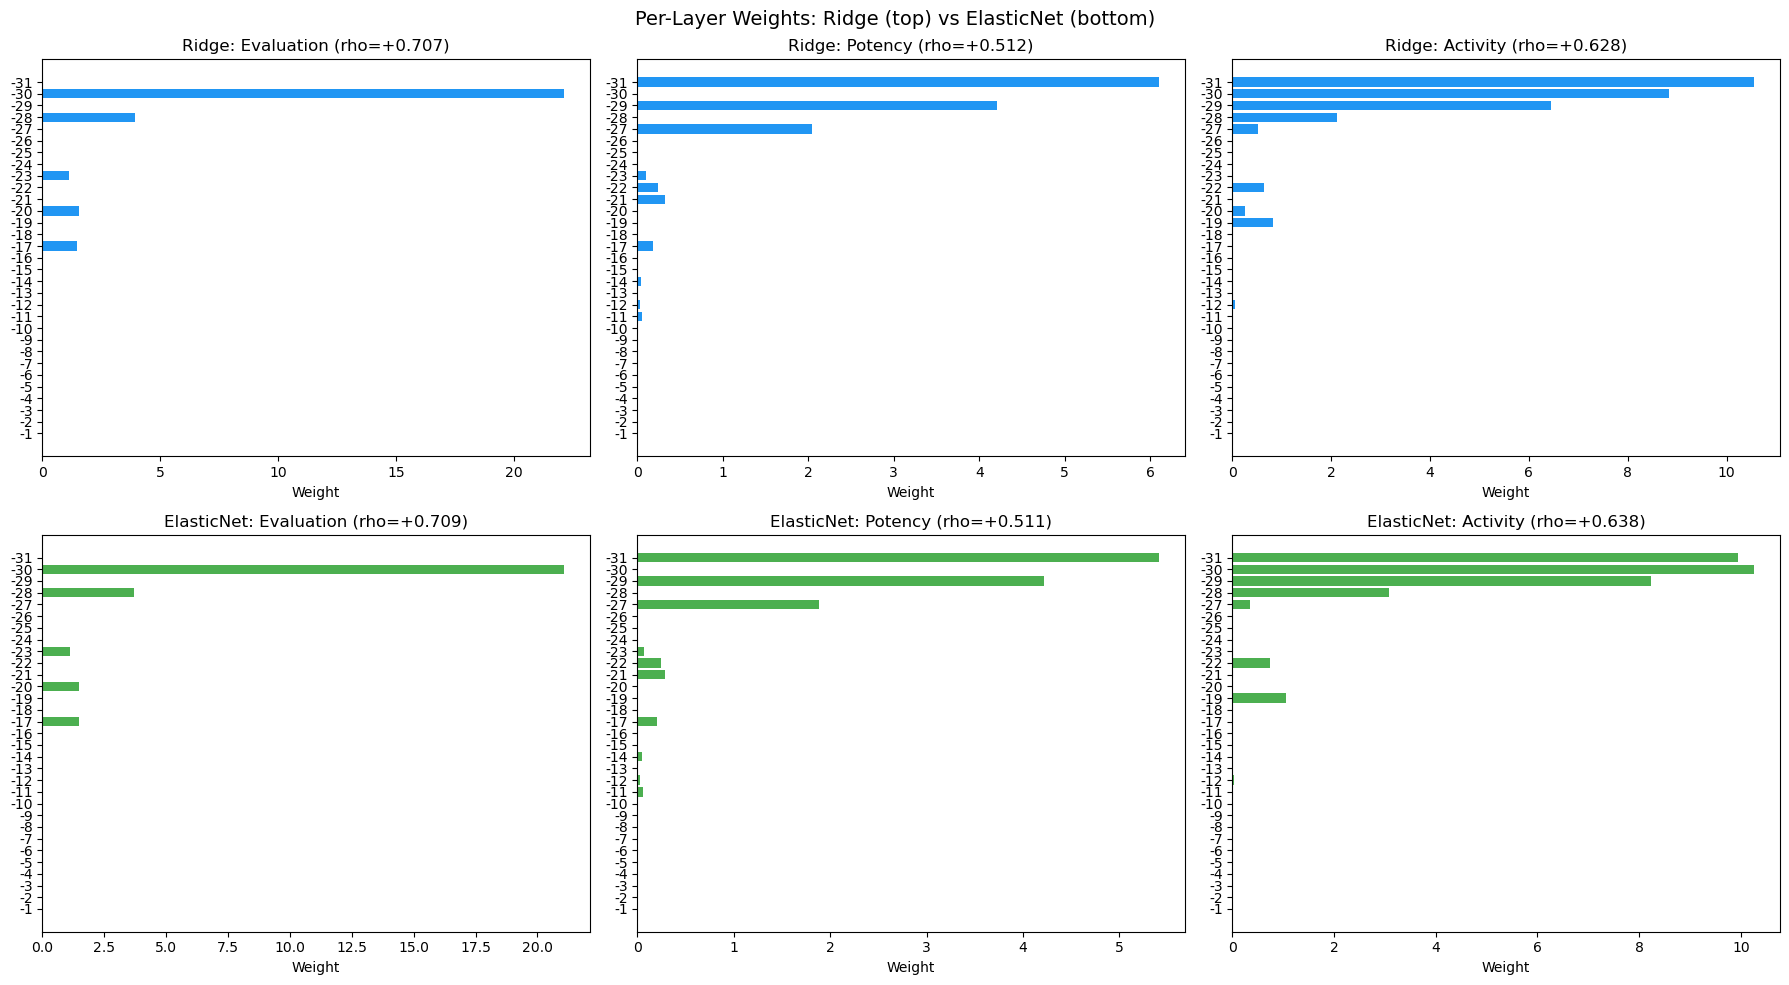

Saved reading_regression_weights.png


In [ ]:
# === Visualize Ridge & ElasticNet Layer Weights ===

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, dim in enumerate(DIMENSIONS):
    sorted_layers = sorted(all_layers)
    
    # Ridge weights
    ridge_w = [ridge_results[dim]['weights_orig'][all_layers.index(l)] for l in sorted_layers]
    colors_r = ['#2196F3' if w > 0 else '#F44336' for w in ridge_w]
    axes[0, idx].barh([str(l) for l in sorted_layers], ridge_w, color=colors_r)
    axes[0, idx].set_xlabel("Weight")
    axes[0, idx].set_title(f"Ridge: {dim.capitalize()} (rho={ridge_results[dim]['rho']:+.3f})")
    axes[0, idx].axvline(0, color='gray', ls='--', alpha=0.5)
    axes[0, idx].invert_yaxis()
    
    # ElasticNet weights
    enet_w = [elasticnet_results[dim]['weights_orig'][all_layers.index(l)] for l in sorted_layers]
    colors_e = ['#4CAF50' if w > 0 else '#FF9800' for w in enet_w]
    axes[1, idx].barh([str(l) for l in sorted_layers], enet_w, color=colors_e)
    axes[1, idx].set_xlabel("Weight")
    axes[1, idx].set_title(f"ElasticNet: {dim.capitalize()} (rho={elasticnet_results[dim]['rho']:+.3f})")
    axes[1, idx].axvline(0, color='gray', ls='--', alpha=0.5)
    axes[1, idx].invert_yaxis()

plt.suptitle("Per-Layer Weights: Ridge (top) vs ElasticNet (bottom)", fontsize=14)
plt.tight_layout()
plt.savefig("reading_regression_weights.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved reading_regression_weights.png")


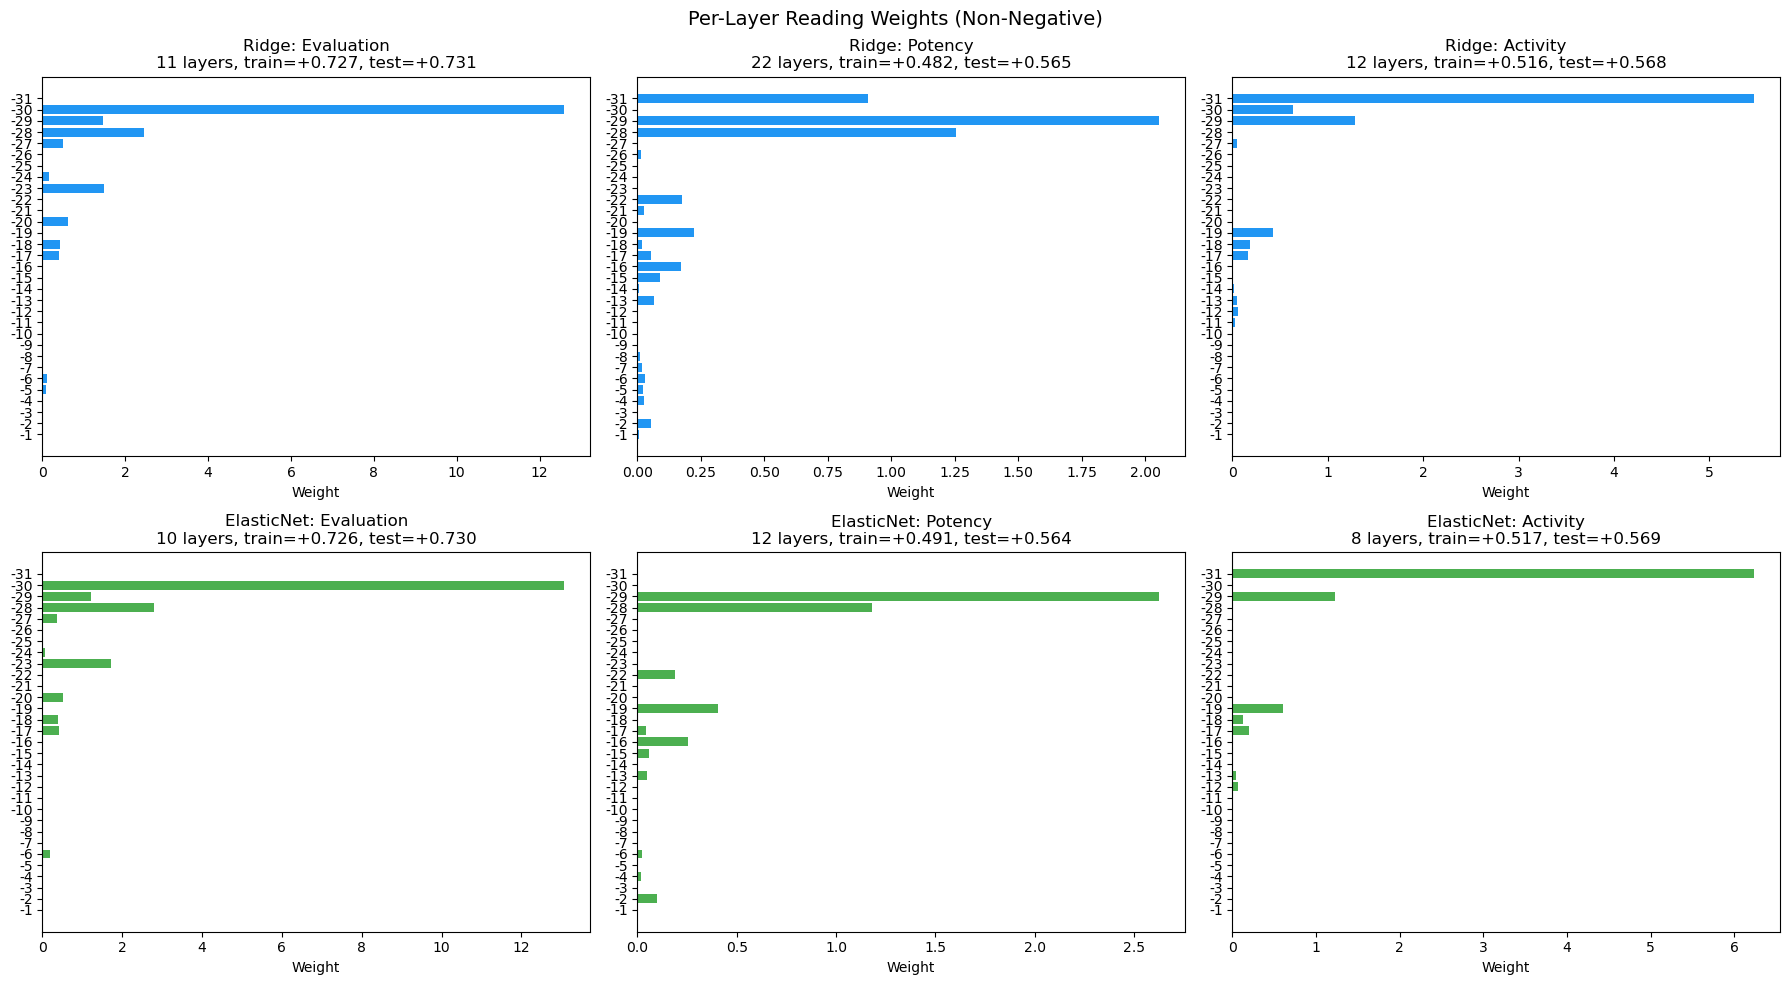

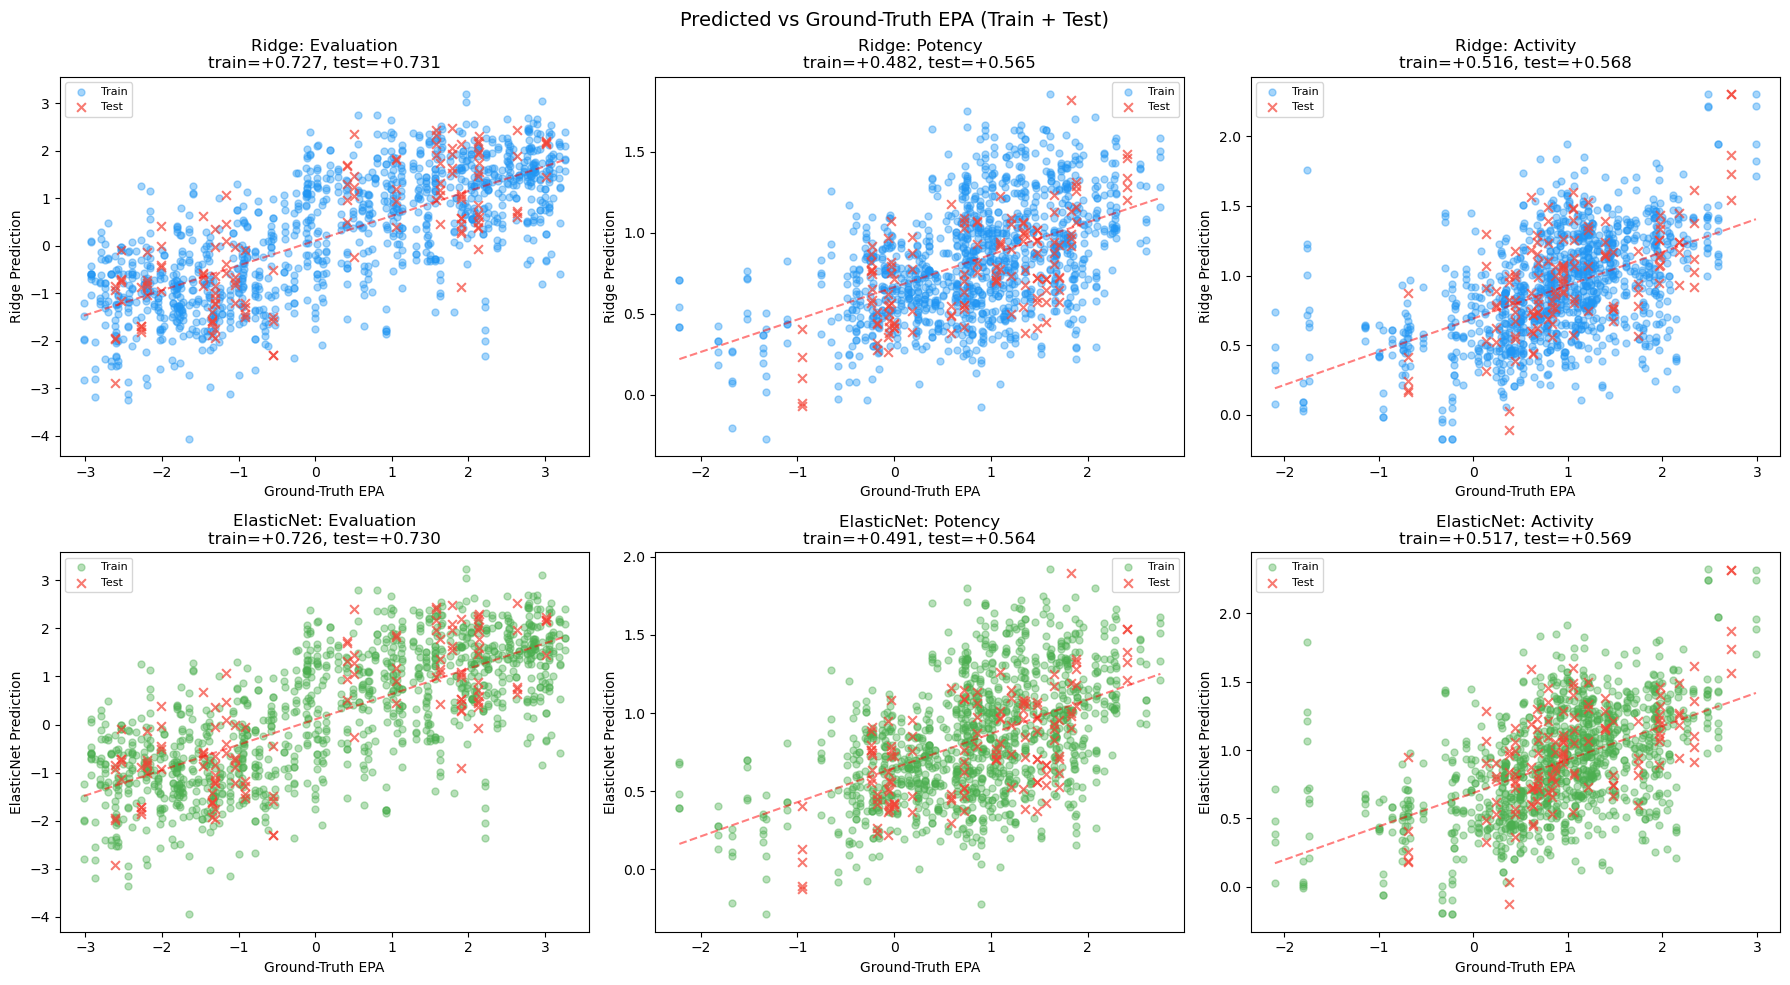

NameError: name 'methods' is not defined

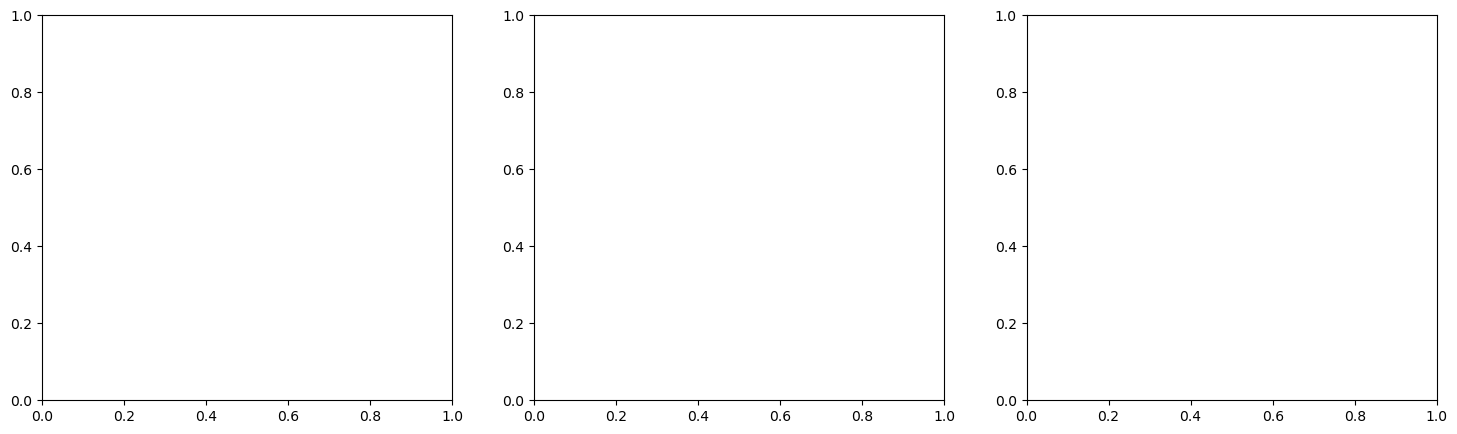

In [10]:
# === Visualization: Ridge & ElasticNet ===
# --- Per-layer weight profiles ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, dim in enumerate(DIMENSIONS):
    sorted_layers = sorted(all_layers)
    # Ridge weights
    ridge_w = [ridge_results[dim]['weights_orig'][all_layers.index(l)] for l in sorted_layers]
    axes[0, idx].barh([str(l) for l in sorted_layers], ridge_w, color='#2196F3')
    axes[0, idx].set_xlabel("Weight")
    axes[0, idx].set_title(f"Ridge: {dim.capitalize()}\n"
                           f"{ridge_results[dim]['n_active']} layers, "
                           f"train={ridge_results[dim]['train_rho']:+.3f}, "
                           f"test={ridge_results[dim]['test_rho']:+.3f}")
    axes[0, idx].axvline(0, color='gray', ls='--', alpha=0.5)
    axes[0, idx].invert_yaxis()
    # ElasticNet weights
    enet_w = [elasticnet_results[dim]['weights_orig'][all_layers.index(l)] for l in sorted_layers]
    axes[1, idx].barh([str(l) for l in sorted_layers], enet_w, color='#4CAF50')
    axes[1, idx].set_xlabel("Weight")
    axes[1, idx].set_title(f"ElasticNet: {dim.capitalize()}\n"
                           f"{elasticnet_results[dim]['n_active']} layers, "
                           f"train={elasticnet_results[dim]['train_rho']:+.3f}, "
                           f"test={elasticnet_results[dim]['test_rho']:+.3f}")
    axes[1, idx].axvline(0, color='gray', ls='--', alpha=0.5)
    axes[1, idx].invert_yaxis()
plt.suptitle("Per-Layer Reading Weights (Non-Negative)", fontsize=14)
plt.tight_layout()
plt.savefig("reading_regression_weights.png", dpi=150, bbox_inches='tight')
plt.show()
# --- Scatter: predicted vs ground truth (train & test) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, dim in enumerate(DIMENSIONS):
    gt_tr = train_gt_arrays[dim]
    gt_te = test_gt_arrays[dim]
    # Ridge scatter
    pred_tr = ridge_results[dim]['train_predictions']
    pred_te = ridge_results[dim]['test_predictions']
    axes[0, idx].scatter(gt_tr, pred_tr, alpha=0.4, s=25, c='#2196F3', label='Train')
    axes[0, idx].scatter(gt_te, pred_te, alpha=0.7, s=40, c='#F44336', marker='x', label='Test')
    all_gt = np.concatenate([gt_tr, gt_te])
    x_line = np.linspace(all_gt.min(), all_gt.max(), 100)
    z = np.polyfit(gt_tr, pred_tr, 1)
    axes[0, idx].plot(x_line, np.polyval(z, x_line), 'r--', alpha=0.5)
    axes[0, idx].set_xlabel("Ground-Truth EPA")
    axes[0, idx].set_ylabel("Ridge Prediction")
    axes[0, idx].set_title(f"Ridge: {dim.capitalize()}\n"
                           f"train={ridge_results[dim]['train_rho']:+.3f}, "
                           f"test={ridge_results[dim]['test_rho']:+.3f}")
    axes[0, idx].legend(fontsize=8)
    # ElasticNet scatter
    pred_tr = elasticnet_results[dim]['train_predictions']
    pred_te = elasticnet_results[dim]['test_predictions']
    axes[1, idx].scatter(gt_tr, pred_tr, alpha=0.4, s=25, c='#4CAF50', label='Train')
    axes[1, idx].scatter(gt_te, pred_te, alpha=0.7, s=40, c='#F44336', marker='x', label='Test')
    z = np.polyfit(gt_tr, pred_tr, 1)
    axes[1, idx].plot(x_line, np.polyval(z, x_line), 'r--', alpha=0.5)
    axes[1, idx].set_xlabel("Ground-Truth EPA")
    axes[1, idx].set_ylabel("ElasticNet Prediction")
    axes[1, idx].set_title(f"ElasticNet: {dim.capitalize()}\n"
                           f"train={elasticnet_results[dim]['train_rho']:+.3f}, "
                           f"test={elasticnet_results[dim]['test_rho']:+.3f}")
    axes[1, idx].legend(fontsize=8)
plt.suptitle("Predicted vs Ground-Truth EPA (Train + Test)", fontsize=14)
plt.tight_layout()
plt.savefig("reading_regression_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
# --- Method comparison bar chart (train vs test) ---
method_names = ['Single Best', 'Greedy', 'Ridge (pos)', 'ElasticNet (pos)']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, dim in enumerate(DIMENSIONS):
    train_rhos = [
        methods['Single Best'][dim]['rho'],
        greedy_results[dim]['train_rho'],
        ridge_results[dim]['train_rho'],
        elasticnet_results[dim]['train_rho'],
    ]
    test_rhos = [
        single_best_test[dim],
        greedy_results[dim]['test_rho'],
        ridge_results[dim]['test_rho'],
        elasticnet_results[dim]['test_rho'],
    ]
    x = np.arange(len(method_names))
    width = 0.35
    axes[idx].bar(x - width/2, train_rhos, width, color='#2196F3', label='Train', alpha=0.8)
    axes[idx].bar(x + width/2, test_rhos,  width, color='#F44336', label='Test',  alpha=0.8)
    axes[idx].set_ylabel("Spearman rho")
    axes[idx].set_title(f"{dim.capitalize()}")
    axes[idx].set_ylim(0, 1)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(method_names, rotation=25, ha='right')
    axes[idx].legend(fontsize=8)
plt.suptitle("Reading Accuracy: Train vs Test", fontsize=13)
plt.tight_layout()
plt.savefig("reading_all_methods_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Visualizations saved.")


In [11]:
# === Compare All Methods on 5 Test Utterances ===
n_examples = 5
example_indices = np.linspace(0, len(test_utterances) - 1, n_examples, dtype=int)
def baseline_reading(dim, idx, raw_scores_split):
    """Uniform average of all sign-corrected layers."""
    vals = []
    for layer in all_layers:
        sign = 1.0 if phase1[dim][layer]['rho'] > 0 else -1.0
        vals.append(sign * raw_scores_split[dim][layer][idx])
    return np.mean(vals)
def greedy_reading(dim, idx, raw_scores_split):
    """Greedy-selected layers with per-layer weights."""
    gr = greedy_results[dim]
    total = 0.0
    total_w = 0.0
    for layer, weight in gr['selected'].items():
        sign = 1.0 if phase1[dim][layer]['rho'] > 0 else -1.0
        total += weight * sign * raw_scores_split[dim][layer][idx]
        total_w += weight
    return total / total_w if total_w > 0 else 0.0
print("=" * 100)
print("COMPARISON ON TEST UTTERANCES: Baseline vs Greedy vs Ridge vs ElasticNet")
print("=" * 100)
for i, idx in enumerate(example_indices):
    u = test_utterances[idx]
    gt_e = u['target_epa']['e']
    gt_p = u['target_epa']['p']
    gt_a = u['target_epa']['a']
    print(f"\n--- Example {i+1} (test idx={idx}) ---")
    print(f"Text: {u['text'][:100]}{'...' if len(u['text']) > 100 else ''}")
    print(f"Ground Truth:    E={gt_e:+6.2f}  P={gt_p:+6.2f}  A={gt_a:+6.2f}")
    print()
    row_fmt = "  {method:<18s}  E={e:+7.3f}  P={p:+7.3f}  A={a:+7.3f}  |  dE={de:+6.3f}  dP={dp:+6.3f}  dA={da:+6.3f}"
    for method_name, read_fn in [("Baseline (all)", lambda d, i: baseline_reading(d, i, test_raw_scores)),
                                  ("Greedy", lambda d, i: greedy_reading(d, i, test_raw_scores)),
                                  ("Ridge (pos)", lambda d, i: ridge_results[d]['test_predictions'][i]),
                                  ("ElasticNet (pos)", lambda d, i: elasticnet_results[d]['test_predictions'][i])]:
        e = read_fn('evaluation', idx)
        p = read_fn('potency', idx)
        a = read_fn('activity', idx)
        print(row_fmt.format(method=method_name, e=e, p=p, a=a,
                             de=e - gt_e, dp=p - gt_p, da=a - gt_a))
print("\n\nNote: dE/dP/dA show deviation from ground truth.")
print("Raw reading values are NOT calibrated to ACT scale — only relative ranking matters.")
print("Spearman rho measures rank correlation, not absolute accuracy.")

COMPARISON ON TEST UTTERANCES: Baseline vs Greedy vs Ridge vs ElasticNet

--- Example 1 (test idx=0) ---
Text: Hey, come join me for a coffee, I just got a new favorite spot downtown!
Ground Truth:    E= +2.13  P= +1.48  A= +0.61

  Baseline (all)      E= +0.600  P= -1.171  A= -0.962  |  dE=-1.530  dP=-2.651  dA=-1.572
  Greedy              E= +0.609  P= -0.006  A= +0.198  |  dE=-1.521  dP=-1.486  dA=-0.412
  Ridge (pos)         E= +0.868  P= +1.018  A= +1.563  |  dE=-1.262  dP=-0.462  dA=+0.953
  ElasticNet (pos)    E= +0.876  P= +1.053  A= +1.593  |  dE=-1.254  dP=-0.427  dA=+0.983

--- Example 2 (test idx=32) ---
Text: Come on, just one more little favor, I'll owe you one, I promise, and it'll be totally worth it, I'l...
Ground Truth:    E= -1.47  P= -0.05  A= +0.86

  Baseline (all)      E= -0.183  P= -1.784  A= -1.469  |  dE=+1.287  dP=-1.734  dA=-2.329
  Greedy              E= +0.228  P= -0.092  A= -0.493  |  dE=+1.698  dP=-0.042  dA=-1.353
  Ridge (pos)         E= -0.659  P= +0.

In [12]:
# === Save All Results Including Ridge & ElasticNet ===
output = {
    "metadata": {
        "model_name": model_name,
        "tuned_at": datetime.now().isoformat(),
        "train_dataset_path": TRAIN_DATASET_PATH,
        "test_dataset_path": TEST_DATASET_PATH,
        "n_train_utterances": len(train_utterances),
        "n_test_utterances": len(test_utterances),
        "n_layers": len(all_layers),
        "method": "representation_reading",
    },
    "phase1_correlations": {},
    "greedy_results": {},
    "ridge_results": {},
    "elasticnet_results": {},
    "method_comparison": {},
}
for dim in DIMENSIONS:
    # Phase 1
    output["phase1_correlations"][dim] = {
        str(l): phase1[dim][l] for l in sorted(phase1[dim].keys())
    }
    # Greedy
    gr = greedy_results[dim]
    sel = gr['selected']
    output["greedy_results"][dim] = {
        "selected_layers": {str(k): v for k, v in sel.items()},
        "layer_signs": {str(l): ("+" if phase1[dim][l]['rho'] > 0 else "-") for l in sel},
        "n_layers": len(sel),
        "train_rho": gr['train_rho'],
        "test_rho": gr['test_rho'],
        "score": gr['score'],
    }
    # Ridge
    rr = ridge_results[dim]
    ridge_layer_weights = {}
    ridge_layer_signs = {}
    for j, layer in enumerate(all_layers):
        w = float(rr['weights_orig'][j])
        if w > 1e-6:
            ridge_layer_weights[str(layer)] = round(w, 6)
            ridge_layer_signs[str(layer)] = "+" if phase1[dim][layer]['rho'] > 0 else "-"
    output["ridge_results"][dim] = {
        "selected_layers": ridge_layer_weights,
        "layer_signs": ridge_layer_signs,
        "n_active": rr['n_active'],
        "alpha": float(rr['alpha']),
        "train_rho": rr['train_rho'],
        "test_rho": rr['test_rho'],
    }
    # ElasticNet
    er = elasticnet_results[dim]
    enet_layer_weights = {}
    enet_layer_signs = {}
    for j, layer in enumerate(all_layers):
        w = float(er['weights_orig'][j])
        if w > 1e-6:
            enet_layer_weights[str(layer)] = round(w, 6)
            enet_layer_signs[str(layer)] = "+" if phase1[dim][layer]['rho'] > 0 else "-"
    output["elasticnet_results"][dim] = {
        "selected_layers": enet_layer_weights,
        "layer_signs": enet_layer_signs,
        "n_active": er['n_active'],
        "alpha": float(er['alpha']),
        "l1_ratio": float(er['l1_ratio']),
        "train_rho": er['train_rho'],
        "test_rho": er['test_rho'],
    }
    # Method comparison
    output["method_comparison"][dim] = {
        "single_best": {
            "train_rho": methods['Single Best'][dim]['rho'],
            "test_rho": single_best_test[dim],
            "n_layers": 1,
        },
        "greedy": {"train_rho": gr['train_rho'], "test_rho": gr['test_rho'], "n_layers": len(sel)},
        "ridge_pos": {"train_rho": rr['train_rho'], "test_rho": rr['test_rho'], "n_layers": rr['n_active']},
        "elasticnet_pos": {"train_rho": er['train_rho'], "test_rho": er['test_rho'], "n_layers": er['n_active']},
    }
with open("epa_reading_tuning_results.json", 'w') as f:
    json.dump(output, f, indent=2)
print("Results saved to epa_reading_tuning_results.json")
print("\n" + "="*70 + "\nSUMMARY (Train / Test)\n" + "="*70)
for dim in DIMENSIONS:
    print(f"\n{dim.upper()}:")
    for method_name in ['single_best', 'greedy', 'ridge_pos', 'elasticnet_pos']:
        mc = output['method_comparison'][dim][method_name]
        print(f"  {method_name:20s}: {mc['n_layers']:2d} layers, "
              f"train_rho={mc['train_rho']:+.3f}, test_rho={mc['test_rho']:+.3f}")

NameError: name 'methods' is not defined

In [21]:
# === Cross-Validated Calibrated Reading ===
# Ridge/ElasticNet with y=ground_truth naturally predicts in EPA scale.
# Use cross_val_predict for honest out-of-sample evaluation.
# This is better than: (1) optimize layers for Spearman → (2) calibrate after.
# Ridge does both in one step, and CV prevents overfitting optimism.

from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

def build_feature_matrix(dim):
    X = np.zeros((len(utterances), len(all_layers)))
    for j, layer in enumerate(all_layers):
        sign = 1.0 if phase1[dim][layer]['rho'] > 0 else -1.0
        X[:, j] = sign * raw_scores[dim][layer]
    return X

cv_ridge_results = {}
cv_enet_results = {}

for dim in DIMENSIONS:
    X = build_feature_matrix(dim)
    y = gt_arrays[dim]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # --- Non-negative Ridge (ElasticNet with tiny l1_ratio) ---
    ridge = ElasticNetCV(
        l1_ratio=[0.01],
        alphas=np.logspace(-4, 4, 50),
        cv=5,
        positive=True,
        max_iter=10000,
    )
    ridge.fit(X_scaled, y)
    
    # Cross-validated predictions (out-of-fold, honest)
    ridge_cv_pred = cross_val_predict(
        ElasticNetCV(l1_ratio=[0.01], alphas=np.logspace(-4, 4, 50),
                     cv=5, positive=True, max_iter=10000),
        X_scaled, y, cv=5
    )
    
    # In-sample predictions (for comparison — these are optimistic)
    ridge_insample_pred = ridge.predict(X_scaled)
    
    ridge_weights_orig = ridge.coef_ / scaler.scale_
    n_active = int(np.sum(ridge_weights_orig > 1e-6))
    
    # Compute comprehensive metrics on CV predictions
    spearman_cv, _ = spearmanr(ridge_cv_pred, y)
    pearson_cv, _ = pearsonr(ridge_cv_pred, y)
    mae_cv = mean_absolute_error(y, ridge_cv_pred)
    rmse_cv = np.sqrt(mean_squared_error(y, ridge_cv_pred))
    r2_cv = r2_score(y, ridge_cv_pred)
    
    # Also compute in-sample metrics for comparison
    spearman_in, _ = spearmanr(ridge_insample_pred, y)
    
    cv_ridge_results[dim] = {
        'model': ridge,
        'scaler': scaler,
        'weights_orig': ridge_weights_orig,
        'alpha': ridge.alpha_,
        'n_active': n_active,
        'cv_predictions': ridge_cv_pred,
        'insample_predictions': ridge_insample_pred,
        'metrics_cv': {
            'spearman': float(spearman_cv),
            'pearson': float(pearson_cv),
            'mae': float(mae_cv),
            'rmse': float(rmse_cv),
            'r2': float(r2_cv),
        },
        'metrics_insample': {'spearman': float(spearman_in)},
    }
    
    print(f"RIDGE+ {dim.upper()}")
    print(f"  In-sample:  rho={spearman_in:+.3f}")
    print(f"  CV (honest): rho={spearman_cv:+.3f}, pearson={pearson_cv:+.3f}, "
          f"MAE={mae_cv:.3f}, RMSE={rmse_cv:.3f}, R²={r2_cv:.3f}")
    print(f"  Active layers: {n_active}/{len(all_layers)}, alpha={ridge.alpha_:.4f}")
    
    # --- Non-negative ElasticNet ---
    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        alphas=np.logspace(-4, 2, 50),
        cv=5,
        positive=True,
        max_iter=10000,
    )
    enet.fit(X_scaled, y)
    
    enet_cv_pred = cross_val_predict(
        ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
                     alphas=np.logspace(-4, 2, 50),
                     cv=5, positive=True, max_iter=10000),
        X_scaled, y, cv=5
    )
    
    enet_insample_pred = enet.predict(X_scaled)
    enet_weights_orig = enet.coef_ / scaler.scale_
    n_active_e = int(np.sum(enet_weights_orig > 1e-6))
    
    spearman_cv_e, _ = spearmanr(enet_cv_pred, y)
    pearson_cv_e, _ = pearsonr(enet_cv_pred, y)
    mae_cv_e = mean_absolute_error(y, enet_cv_pred)
    rmse_cv_e = np.sqrt(mean_squared_error(y, enet_cv_pred))
    r2_cv_e = r2_score(y, enet_cv_pred)
    spearman_in_e, _ = spearmanr(enet_insample_pred, y)
    
    cv_enet_results[dim] = {
        'model': enet,
        'scaler': scaler,
        'weights_orig': enet_weights_orig,
        'alpha': enet.alpha_,
        'l1_ratio': enet.l1_ratio_,
        'n_active': n_active_e,
        'cv_predictions': enet_cv_pred,
        'insample_predictions': enet_insample_pred,
        'metrics_cv': {
            'spearman': float(spearman_cv_e),
            'pearson': float(pearson_cv_e),
            'mae': float(mae_cv_e),
            'rmse': float(rmse_cv_e),
            'r2': float(r2_cv_e),
        },
        'metrics_insample': {'spearman': float(spearman_in_e)},
    }
    
    print(f"ENET+  {dim.upper()}")
    print(f"  In-sample:  rho={spearman_in_e:+.3f}")
    print(f"  CV (honest): rho={spearman_cv_e:+.3f}, pearson={pearson_cv_e:+.3f}, "
          f"MAE={mae_cv_e:.3f}, RMSE={rmse_cv_e:.3f}, R²={r2_cv_e:.3f}")
    print(f"  Active layers: {n_active_e}/{len(all_layers)}, "
          f"alpha={enet.alpha_:.4f}, l1_ratio={enet.l1_ratio_:.1f}")
    print()


RIDGE+ EVALUATION
  In-sample:  rho=+0.707
  CV (honest): rho=+0.659, pearson=+0.697, MAE=1.165, RMSE=1.464, R²=0.483
  Active layers: 7/31, alpha=0.0001
ENET+  EVALUATION
  In-sample:  rho=+0.709
  CV (honest): rho=+0.661, pearson=+0.696, MAE=1.166, RMSE=1.464, R²=0.483
  Active layers: 7/31, alpha=0.0212, l1_ratio=0.9

RIDGE+ POTENCY
  In-sample:  rho=+0.512
  CV (honest): rho=+0.392, pearson=+0.452, MAE=0.653, RMSE=0.808, R²=0.201
  Active layers: 11/31, alpha=0.1265
ENET+  POTENCY
  In-sample:  rho=+0.511
  CV (honest): rho=+0.393, pearson=+0.447, MAE=0.651, RMSE=0.810, R²=0.197
  Active layers: 11/31, alpha=0.1151, l1_ratio=0.1

RIDGE+ ACTIVITY
  In-sample:  rho=+0.628
  CV (honest): rho=+0.510, pearson=+0.543, MAE=0.675, RMSE=0.834, R²=0.289
  Active layers: 10/31, alpha=0.1265
ENET+  ACTIVITY
  In-sample:  rho=+0.638
  CV (honest): rho=+0.518, pearson=+0.545, MAE=0.678, RMSE=0.836, R²=0.286
  Active layers: 9/31, alpha=0.0494, l1_ratio=0.1



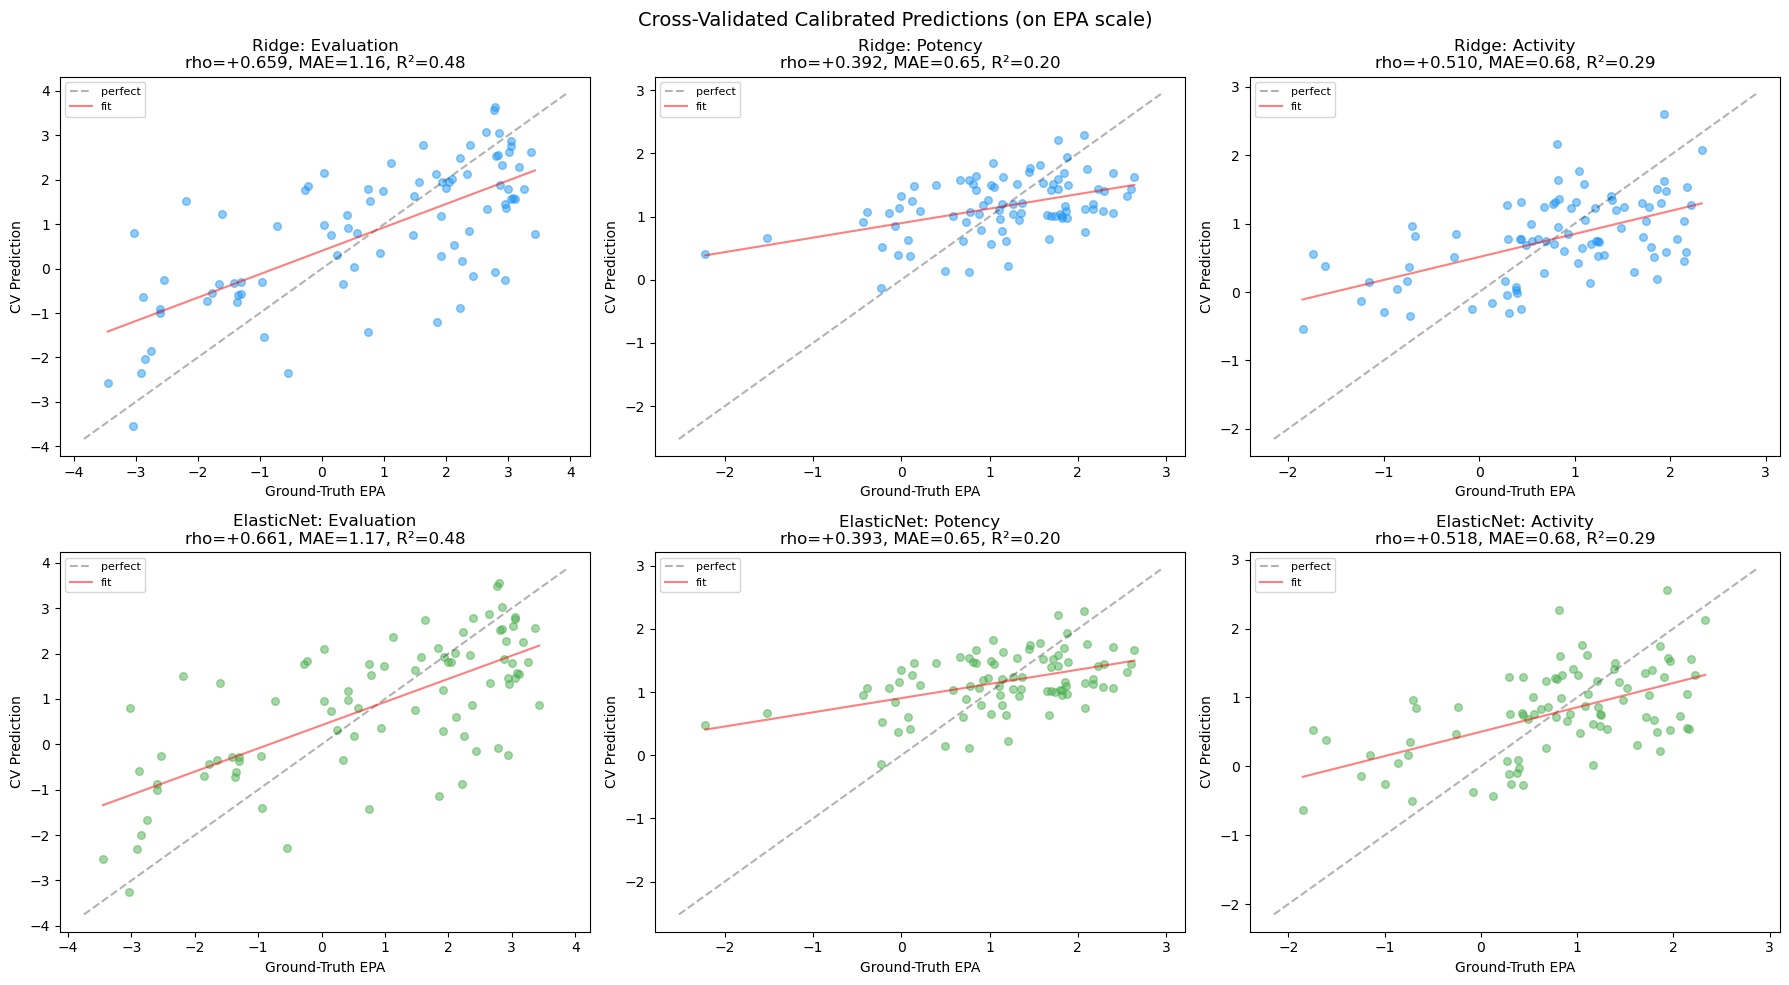

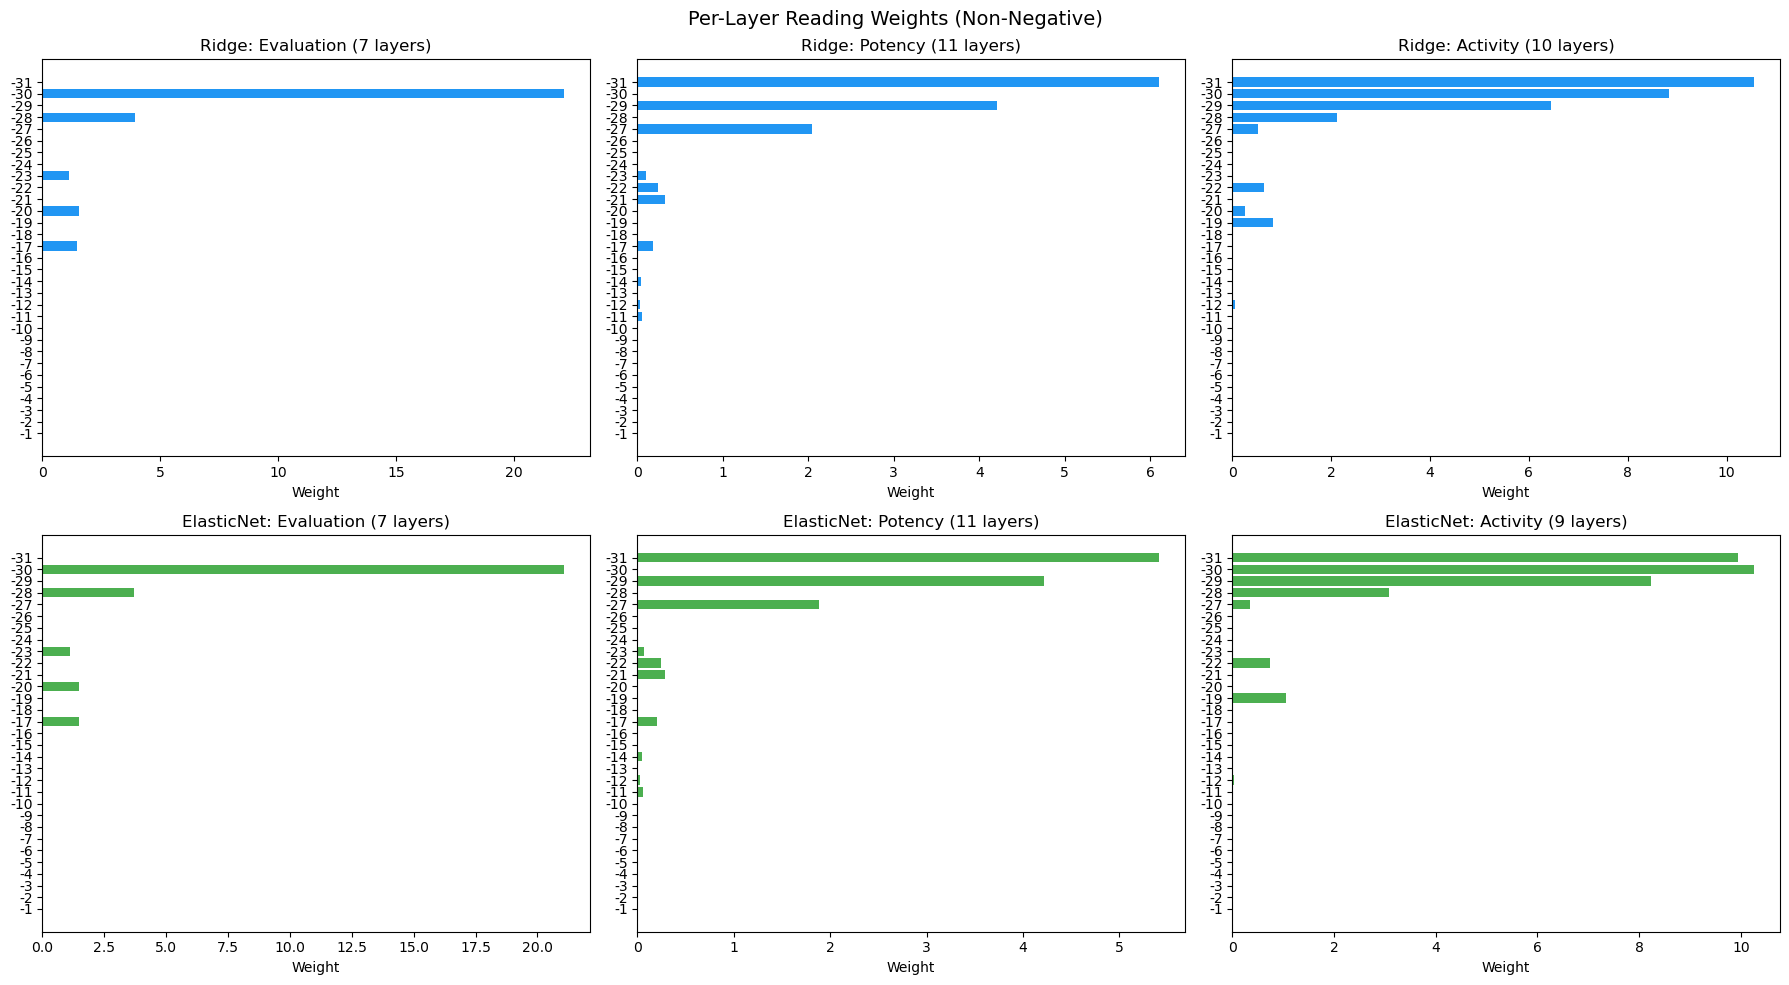

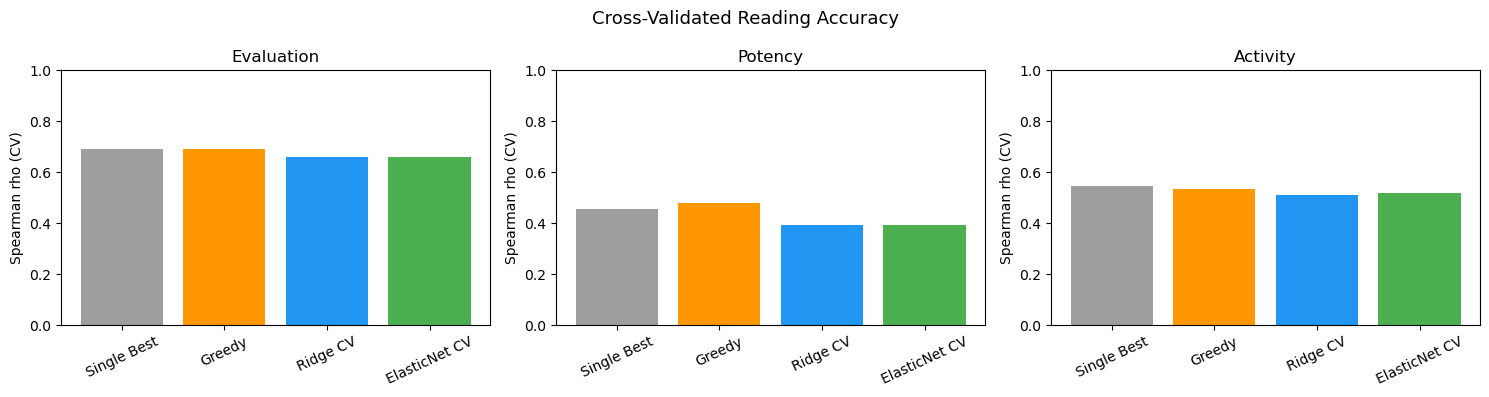

Visualizations saved.


In [22]:
# === Visualization: CV-Calibrated Predictions vs Ground Truth ===

# --- Scatter plots: CV predictions vs ground truth (already on EPA scale!) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, dim in enumerate(DIMENSIONS):
    gt = gt_arrays[dim]
    
    # Ridge CV predictions
    pred = cv_ridge_results[dim]['cv_predictions']
    m = cv_ridge_results[dim]['metrics_cv']
    axes[0, idx].scatter(gt, pred, alpha=0.5, s=30, c='#2196F3')
    # Perfect calibration line
    lims = [min(gt.min(), pred.min()) - 0.3, max(gt.max(), pred.max()) + 0.3]
    axes[0, idx].plot(lims, lims, 'k--', alpha=0.3, label='perfect')
    # Fit line
    z = np.polyfit(gt, pred, 1)
    x_line = np.linspace(gt.min(), gt.max(), 100)
    axes[0, idx].plot(x_line, np.polyval(z, x_line), 'r-', alpha=0.5, label='fit')
    axes[0, idx].set_xlabel("Ground-Truth EPA")
    axes[0, idx].set_ylabel("CV Prediction")
    axes[0, idx].set_title(f"Ridge: {dim.capitalize()}\n"
                           f"rho={m['spearman']:+.3f}, MAE={m['mae']:.2f}, R²={m['r2']:.2f}")
    axes[0, idx].legend(fontsize=8)
    
    # ElasticNet CV predictions
    pred = cv_enet_results[dim]['cv_predictions']
    m = cv_enet_results[dim]['metrics_cv']
    axes[1, idx].scatter(gt, pred, alpha=0.5, s=30, c='#4CAF50')
    lims = [min(gt.min(), pred.min()) - 0.3, max(gt.max(), pred.max()) + 0.3]
    axes[1, idx].plot(lims, lims, 'k--', alpha=0.3, label='perfect')
    z = np.polyfit(gt, pred, 1)
    axes[1, idx].plot(x_line, np.polyval(z, x_line), 'r-', alpha=0.5, label='fit')
    axes[1, idx].set_xlabel("Ground-Truth EPA")
    axes[1, idx].set_ylabel("CV Prediction")
    axes[1, idx].set_title(f"ElasticNet: {dim.capitalize()}\n"
                           f"rho={m['spearman']:+.3f}, MAE={m['mae']:.2f}, R²={m['r2']:.2f}")
    axes[1, idx].legend(fontsize=8)

plt.suptitle("Cross-Validated Calibrated Predictions (on EPA scale)", fontsize=14)
plt.tight_layout()
plt.savefig("reading_cv_calibrated_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Weight profiles ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, dim in enumerate(DIMENSIONS):
    sorted_layers = sorted(all_layers)
    
    ridge_w = [cv_ridge_results[dim]['weights_orig'][all_layers.index(l)] for l in sorted_layers]
    axes[0, idx].barh([str(l) for l in sorted_layers], ridge_w, color='#2196F3')
    axes[0, idx].set_xlabel("Weight")
    axes[0, idx].set_title(f"Ridge: {dim.capitalize()} ({cv_ridge_results[dim]['n_active']} layers)")
    axes[0, idx].axvline(0, color='gray', ls='--', alpha=0.5)
    axes[0, idx].invert_yaxis()
    
    enet_w = [cv_enet_results[dim]['weights_orig'][all_layers.index(l)] for l in sorted_layers]
    axes[1, idx].barh([str(l) for l in sorted_layers], enet_w, color='#4CAF50')
    axes[1, idx].set_xlabel("Weight")
    axes[1, idx].set_title(f"ElasticNet: {dim.capitalize()} ({cv_enet_results[dim]['n_active']} layers)")
    axes[1, idx].axvline(0, color='gray', ls='--', alpha=0.5)
    axes[1, idx].invert_yaxis()

plt.suptitle("Per-Layer Reading Weights (Non-Negative)", fontsize=14)
plt.tight_layout()
plt.savefig("reading_cv_weights.png", dpi=150, bbox_inches='tight')
plt.show()

# --- All methods comparison ---
method_names = ['Single Best', 'Greedy', 'Ridge CV', 'ElasticNet CV']
method_colors = ['#9E9E9E', '#FF9800', '#2196F3', '#4CAF50']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, dim in enumerate(DIMENSIONS):
    rhos = [
        methods['Single Best'][dim]['rho'],
        methods['Greedy'][dim]['rho'],
        cv_ridge_results[dim]['metrics_cv']['spearman'],
        cv_enet_results[dim]['metrics_cv']['spearman'],
    ]
    axes[idx].bar(method_names, rhos, color=method_colors)
    axes[idx].set_ylabel("Spearman rho (CV)")
    axes[idx].set_title(f"{dim.capitalize()}")
    axes[idx].set_ylim(0, 1)
    axes[idx].tick_params(axis='x', rotation=25)
plt.suptitle("Cross-Validated Reading Accuracy", fontsize=13)
plt.tight_layout()
plt.savefig("reading_cv_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Visualizations saved.")
